In [1]:
import glob, os, numpy as np

# --- find the preprocessed cache ---
cache = (sorted(glob.glob("artifacts/cache/*all*128hz*.npz")) or sorted(glob.glob("artifacts/cache/*.npz")))[0]
print(f"[cache] {cache}  ({os.path.getsize(cache)/1e6:.1f} MB)\n")

z = np.load(cache, allow_pickle=True)
print("[keys in cache]")
for k in z.files:
    v = z[k]; print(f"  {k:14s} shape={getattr(v,'shape',None)} dtype={getattr(v,'dtype',None)}")
print()

def pick(*names):
    for n in names:
        if n in z.files: return n
    return None
kX   = pick("X","windows","data","x")
kSub = pick("subjects","subject","subject_ids","y_subject","labels","y")
kSess= pick("sessions","session","session_ids")
kStim= pick("stimuli","stimulus","stim","stimulus_ids")
X = z[kX] if kX else None
arr = lambda k: np.asarray(z[k]).ravel() if k else None
sub, sess, stim = arr(kSub), arr(kSess), arr(kStim)

if X is not None:
    print("="*60); print("CORE WINDOW TENSOR")
    print(f"  total windows (samples) : {X.shape[0]:,}")
    if X.ndim==3: print(f"  per-window shape        : {X.shape[1]} channels x {X.shape[2]} time points")
    print(f"  dtype                   : {X.dtype}")
    print(f"  value min / max         : {np.nanmin(X):.3f} / {np.nanmax(X):.3f}")
    print(f"  global mean / std       : {np.nanmean(X):.4f} / {np.nanstd(X):.4f}  (z-scored -> ~0/~1)")
    print(f"  NaNs                    : {int(np.isnan(X).sum())}\n")

def dist(name, v):
    if v is None: print(f"[{name}] key not found\n"); return
    u,c = np.unique(v, return_counts=True)
    print(f"[{name}] {len(u)} unique")
    for i in np.argsort(-c): print(f"    {str(u[i]):>10s} : {c[i]:>7,}")
    print(f"    per-group windows  min/median/max: {c.min():,} / {int(np.median(c)):,} / {c.max():,}\n")

print("="*60); print("SUBJECTS"); dist("subjects", sub)
print("="*60); print("SESSIONS"); dist("sessions", sess)
print("="*60); print("STIMULI");  dist("stimuli",  stim)

if sub is not None and sess is not None:
    print("="*60); print("WINDOWS per SUBJECT x SESSION")
    su, ss = np.unique(sub), np.unique(sess)
    print("subj\\sess  " + "".join(f"{str(s):>9s}" for s in ss))
    for u in su:
        print(f"{str(u):>9s}  " + "".join(f"{int(((sub==u)&(sess==s)).sum()):>9,}" for s in ss))
    print()

if X is not None and X.ndim==3:
    print("="*60); print("PER-CHANNEL mean/std (z-scored ~0/~1)")
    cm, cs = np.nanmean(X,axis=(0,2)), np.nanstd(X,axis=(0,2))
    for i,(m,s) in enumerate(zip(cm,cs)): print(f"  ch{i:02d}: mean={m:+.3f} std={s:.3f}")
print("\nDone.")

[cache] artifacts/cache/bed_windows_all_128hz_2.0s.npz  (766.4 MB)

[keys in cache]
  X              shape=(57495, 14, 256) dtype=float32
  y              shape=(57495,) dtype=int64
  session        shape=(57495,) dtype=object
  stimulus       shape=(57495,) dtype=object
  quality        shape=(57495,) dtype=float32
  subjects       shape=(21,) dtype=object
  channels       shape=(14,) dtype=object

CORE WINDOW TENSOR
  total windows (samples) : 57,495
  per-window shape        : 14 channels x 256 time points
  dtype                   : float32
  value min / max         : -144.994 / 124.475
  global mean / std       : 0.0000 / 1.0050  (z-scored -> ~0/~1)
  NaNs                    : 0

SUBJECTS
[subjects] 21 unique
           s01 :       1
           s02 :       1
           s03 :       1
           s04 :       1
           s05 :       1
           s06 :       1
           s07 :       1
           s08 :       1
           s09 :       1
           s10 :       1
           s11 :       1
 

ValueError: operands could not be broadcast together with shapes (21,) (57495,) 

In [2]:
# per-window subject id is in `y`; `subjects` maps id -> name
y = np.asarray(z["y"]).ravel()
names = np.asarray(z["subjects"]).ravel()      # length 21
sess  = np.asarray(z["session"]).ravel()
qual  = np.asarray(z["quality"]).ravel()
sub_name = np.array([names[i] if i < len(names) else str(i) for i in y])  # readable labels

print("="*60); print("WINDOWS per SUBJECT")
u,c = np.unique(sub_name, return_counts=True)
for i in np.argsort(u): print(f"    {str(u[i]):>6s} : {c[i]:>6,}")
print(f"    per-subject  min/median/max: {c.min():,} / {int(np.median(c)):,} / {c.max():,}\n")

print("="*60); print("WINDOWS per SUBJECT x SESSION")
ss = np.unique(sess)
print("subj   " + "".join(f"{str(s):>9s}" for s in ss))
for nm in np.unique(sub_name):
    print(f"{str(nm):>5s}  " + "".join(f"{int(((sub_name==nm)&(sess==s)).sum()):>9,}" for s in ss))
print()

print("="*60); print("QUALITY SCORE")
print(f"  min/mean/median/max : {qual.min():.3f} / {qual.mean():.3f} / {np.median(qual):.3f} / {qual.max():.3f}")
print(f"  windows >= 0.35 gate: {(qual>=0.35).sum():,} / {len(qual):,}  ({100*(qual>=0.35).mean():.1f}%)")

WINDOWS per SUBJECT
       s01 :  2,687
       s02 :  2,712
       s03 :  2,730
       s04 :  2,742
       s05 :  2,811
       s06 :  2,775
       s07 :  2,770
       s08 :  2,753
       s09 :  2,762
       s10 :  2,760
       s11 :  2,820
       s12 :  2,788
       s13 :  2,791
       s14 :  2,630
       s15 :  2,683
       s16 :  2,792
       s17 :  2,752
       s18 :  2,662
       s19 :  2,711
       s20 :  2,747
       s21 :  2,617
    per-subject  min/median/max: 2,617 / 2,752 / 2,820

WINDOWS per SUBJECT x SESSION
subj         r01      r02      r03
  s01        911      886      890
  s02        919      924      869
  s03        938      919      873
  s04        918      938      886
  s05        953      938      920
  s06        921      899      955
  s07        929      920      921
  s08        918      938      897
  s09        914      923      925
  s10        902      920      938
  s11        950      938      932
  s12        912      921      955
  s13        936   

In [3]:
# ============================================================================
# BED PREPROCESSED DATA — TRANSPARENCY INSPECTION
# Purpose: open the preprocessed cache and verify, in plain language, exactly
#          what the model is fed: how many samples, their shape, and balance.
# A "window" = one 2-second slice of EEG = the basic input sample to the model.
# ============================================================================
import glob, os, numpy as np

cache = (sorted(glob.glob("artifacts/cache/*all*128hz*.npz")) or sorted(glob.glob("artifacts/cache/*.npz")))[0]
z = np.load(cache, allow_pickle=True)
X        = z["X"]                       # the EEG windows fed to the model
y        = np.asarray(z["y"]).ravel()   # which subject each window belongs to (0..20)
names    = np.asarray(z["subjects"]).ravel()
session  = np.asarray(z["session"]).ravel()
stimulus = np.asarray(z["stimulus"]).ravel()
quality  = np.asarray(z["quality"]).ravel()
subj     = np.array([names[i] for i in y])     # readable subject names

print(f"CACHE FILE : {cache}  ({os.path.getsize(cache)/1e6:.1f} MB)\n")

print("="*70)
print("1) WHAT IS ONE INPUT SAMPLE?")
print(f"   Each sample is one EEG 'window': {X.shape[1]} channels x {X.shape[2]} time points")
print(f"   = 2.0 seconds of brain signal at 128 Hz from a 14-electrode headset.")
print(f"   Stored as {X.dtype}; the model reads these {X.shape[1]}x{X.shape[2]} matrices directly.\n")

print("="*70)
print("2) HOW MANY SAMPLES IN TOTAL?")
print(f"   TOTAL windows = {X.shape[0]:,}   (this is the full dataset size)")
print(f"   NaNs (missing values) = {int(np.isnan(X).sum())}  -> data is clean.\n")

print("="*70)
print("3) IS THE DATA PROPERLY NORMALISED (z-scored)?")
print(f"   global mean = {X.mean():.4f}  global std = {X.std():.4f}")
print(f"   WHAT THIS SHOWS: mean~0 and std~1 confirm per-channel z-scoring worked,")
print(f"   so no single channel dominates the model.\n")

def section(title, labels, explain):
    print("="*70); print(title)
    u,c = np.unique(labels, return_counts=True)
    for i in np.argsort(u): print(f"   {str(u[i]):>10s} : {c[i]:>7,} windows")
    print(f"   balance (min/median/max) = {c.min():,} / {int(np.median(c)):,} / {c.max():,}")
    print(f"   WHAT THIS SHOWS: {explain}\n")

section("4) WINDOWS PER SUBJECT (identities to tell apart)", subj,
        "each of the 21 people contributes a similar amount -> no person is over/under-represented.")
section("5) WINDOWS PER SESSION (recording days)", session,
        "r01/r02/r03 are separate days; balanced counts let us test CROSS-SESSION reliability fairly.")
section("6) WINDOWS PER STIMULUS (what the person was doing)", stimulus,
        "13 task conditions (rest, cognitive, image, SSVEP...) - the model sees varied brain states.")

print("="*70)
print("7) SIGNAL-QUALITY GATE")
print(f"   quality score  min/mean/median = {quality.min():.3f} / {quality.mean():.3f} / {np.median(quality):.3f}")
print(f"   windows passing the >=0.35 quality gate: {(quality>=0.35).sum():,} / {len(quality):,} (100%)")
print(f"   WHAT THIS SHOWS: noisy/flatline windows were already removed during preprocessing,")
print(f"   so every stored window is usable.\n")

print("="*70)
print("SUMMARY (one line): 57,495 clean, z-scored, quality-gated 2 s windows")
print("(14 channels x 256 samples), balanced across 21 subjects and 3 sessions, 13 stimuli.")

CACHE FILE : artifacts/cache/bed_windows_all_128hz_2.0s.npz  (766.4 MB)

1) WHAT IS ONE INPUT SAMPLE?
   Each sample is one EEG 'window': 14 channels x 256 time points
   = 2.0 seconds of brain signal at 128 Hz from a 14-electrode headset.
   Stored as float32; the model reads these 14x256 matrices directly.

2) HOW MANY SAMPLES IN TOTAL?
   TOTAL windows = 57,495   (this is the full dataset size)
   NaNs (missing values) = 0  -> data is clean.

3) IS THE DATA PROPERLY NORMALISED (z-scored)?
   global mean = 0.0000  global std = 1.0050
   WHAT THIS SHOWS: mean~0 and std~1 confirm per-channel z-scoring worked,
   so no single channel dominates the model.

4) WINDOWS PER SUBJECT (identities to tell apart)
          s01 :   2,687 windows
          s02 :   2,712 windows
          s03 :   2,730 windows
          s04 :   2,742 windows
          s05 :   2,811 windows
          s06 :   2,775 windows
          s07 :   2,770 windows
          s08 :   2,753 windows
          s09 :   2,762 windows

In [4]:
# ============================================================================
# STEP 1 — PREPROCESSING WALKTHROUGH for ONE SUBJECT (transparency for supervisor)
# Shows the SAME raw EEG recording after EACH preprocessing stage, with plots +
# a stats table, exactly matching fed_real_bed/data.py::preprocess_signal.
# Paste into a Jupyter cell in ~/24PHD1237/BED/FED_REAL_BED_ALL and run.
# ============================================================================
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import signal
from fed_real_bed.config import load_config
from fed_real_bed.data import discover_manifest, load_raw_signal
 
# --- 0. config + pick ONE recording (subject / session / stimulus) ---
cfg = load_config("configs/brev_gpu_p0_ecapa_ccpm.yaml")
D   = cfg.raw["data"]
channels = list(D["channels"])
fs_in    = int(D["input_sampling_rate"])     # 256
fs_out   = int(D["target_sampling_rate"])    # 128
lo, hi   = D["bandpass_hz"]                   # 1, 45
notch    = D.get("notch_hz")                  # 50
 
man = discover_manifest(cfg)
PICK_SUBJECT = sorted(man["subject"].unique())[4]   # 5th subject (change index to pick another)
row = man[man["subject"]==PICK_SUBJECT].iloc[0]     # first (session,stimulus) of that subject
print(f"Subject={row['subject']}  session={row['session']}  stimulus={row['stimulus']}")
print(f"file: {row['path']}\n")
 
raw = load_raw_signal(row["path"], channels)        # shape (14, T) at 256 Hz
print(f"RAW shape: {raw.shape}  (14 channels x {raw.shape[1]} samples @ {fs_in} Hz "
      f"= {raw.shape[1]/fs_in:.1f} s)\n")
 
# --- 1..4 apply each stage, KEEPING the intermediate result ---
stages = {}
stages["1. RAW (256 Hz)"] = raw.copy()
 
sos = signal.butter(4, [lo, hi], btype="bandpass", fs=fs_in, output="sos")
bp  = signal.sosfiltfilt(sos, raw, axis=1).astype(np.float32)
stages[f"2. Band-pass {lo}-{hi} Hz"] = bp
 
nt = bp
if notch:
    b,a = signal.iirnotch(float(notch), Q=30.0, fs=fs_in)
    nt = signal.filtfilt(b, a, bp, axis=1).astype(np.float32)
stages[f"3. Notch {notch} Hz"] = nt
 
tgt_len = int(round(nt.shape[1] * fs_out / fs_in))
rs = signal.resample(nt, tgt_len, axis=1).astype(np.float32)
stages[f"4. Resample {fs_out} Hz"] = rs
 
zs = ((rs - rs.mean(axis=1, keepdims=True)) / (rs.std(axis=1, keepdims=True)+1e-6)).astype(np.float32)
stages["5. Per-channel z-score"] = zs
 
# --- stats table (per stage) ---
def stats(x, fs):
    return dict(channels=x.shape[0], samples=x.shape[1], seconds=round(x.shape[1]/fs,2),
                mean=round(float(x.mean()),4), std=round(float(x.std()),4),
                min=round(float(x.min()),2), max=round(float(x.max()),2))
fs_of = {"1":256,"2":256,"3":256,"4":128,"5":128}
tab = []
for name,x in stages.items():
    f = 128 if name.startswith(("4","5")) else 256
    tab.append({"stage":name, **stats(x,f)})
df = pd.DataFrame(tab)
print("PER-STAGE STATISTICS (one channel-set of this recording):")
print(df.to_string(index=False)); print()
 
# --- plot: one channel (O1) through every stage ---
ch = channels.index("O1") if "O1" in channels else 0
fig,ax = plt.subplots(len(stages),1, figsize=(11,10), sharex=False)
for i,(name,x) in enumerate(stages.items()):
    f = 128 if name.startswith(("4","5")) else 256
    t = np.arange(min(x.shape[1], f*3))/f          # first 3 seconds
    ax[i].plot(t, x[ch,:len(t)], lw=0.7, color="#2c6fbb")
    ax[i].set_ylabel(name, fontsize=8); ax[i].grid(alpha=0.3)
ax[-1].set_xlabel("time (s)")
fig.suptitle(f"Step 1 Preprocessing — subject {row['subject']} {row['session']} "
             f"{row['stimulus']}, channel {channels[ch]} (first 3 s)", fontsize=11)
fig.tight_layout(); fig.savefig("step1_preprocessing.png", dpi=160, bbox_inches="tight")
print("[saved] step1_preprocessing.png")
 
# --- 6. windowing: how the cleaned signal becomes model inputs ---
win = int(round(D["window_sec"]*fs_out))           # 2.0 s * 128 = 256
n_win = zs.shape[1]//win
print(f"\nWINDOWING: 2.0 s windows = {win} samples each ->  this recording yields "
      f"{n_win} windows of shape (14 x {win}).")
print("Each such 14 x 256 window is ONE input sample to the encoder (next step).")

FileNotFoundError: BED raw root not found: /home/nvidia/24PHD1237/BED/FED_REAL_BED/DATASET/BED/RAW_PARSED

In [5]:
print("="*78); print("OFFICIAL BED DATASET — what the dataset IS (from the paper)"); print("="*78)
official = [
 ("Recording device", "Emotiv EPOC+ — a low-cost CONSUMER wireless EEG headset"),
 ("Why it matters",   "consumer-grade = noisier than medical caps -> a HARD, realistic benchmark"),
 ("EEG channels",     "14 electrodes: AF3 F7 F3 FC5 T7 P7 O1 O2 P8 T8 FC6 F4 F8 AF4"),
 ("Electrode system", "extends the international 10-20 system; reference = M1/M2 mastoids"),
 ("Sampling rate",    "256 Hz (256 samples per second, per channel)"),
 ("On-device filters","built-in 5th-order sinc filter + digital notch at 50/60 Hz (mains hum)"),
 ("Subjects",         "21 participants (the identities to be recognised)"),
 ("Sessions",         "3, CHRONOLOGICALLY DISJOINT (different days) -> tests time stability"),
 ("Stimuli",          "12 stimuli, 4 categories: affective images, cognitive (math),"),
 ("",                 "    SSVEP flicker (3/5/7/10 Hz + colour), resting eyes open/closed"),
 ("Purpose",          "first PUBLIC dataset for CROSS-SESSION EEG biometrics on consumer hardware"),
 ("Reference",        "Arnau-Gonzalez et al., IEEE IoT J 8(15):12219-12230, 2021; DOI 10.1109/JIOT.2021.3061727"),
]
for k,v in official: print(f"  {k:18s}: {v}")
print("""
GLOSSARY:
  EEG          = electrical brain activity from scalp electrodes.
  channel      = one electrode's time-signal (14 channels = 14 parallel signals).
  sampling rate= measurements per second (256 Hz).
  session      = one recording day; 'cross-session' = enrol one day, test another.
  stimulus     = what the person was doing/seeing (rest, math, flicker...).
  SSVEP        = brain response to a flickering light at a fixed frequency.
  biometrics   = recognising a person from a signal (EEG = a 'brain password').
NOTE: paper says 12 stimuli; our cache lists 13 labels (eyes-open RO + eyes-closed RC split).
""")

OFFICIAL BED DATASET — what the dataset IS (from the paper)
  Recording device  : Emotiv EPOC+ — a low-cost CONSUMER wireless EEG headset
  Why it matters    : consumer-grade = noisier than medical caps -> a HARD, realistic benchmark
  EEG channels      : 14 electrodes: AF3 F7 F3 FC5 T7 P7 O1 O2 P8 T8 FC6 F4 F8 AF4
  Electrode system  : extends the international 10-20 system; reference = M1/M2 mastoids
  Sampling rate     : 256 Hz (256 samples per second, per channel)
  On-device filters : built-in 5th-order sinc filter + digital notch at 50/60 Hz (mains hum)
  Subjects          : 21 participants (the identities to be recognised)
  Sessions          : 3, CHRONOLOGICALLY DISJOINT (different days) -> tests time stability
  Stimuli           : 12 stimuli, 4 categories: affective images, cognitive (math),
                    :     SSVEP flicker (3/5/7/10 Hz + colour), resting eyes open/closed
  Purpose           : first PUBLIC dataset for CROSS-SESSION EEG biometrics on consumer hardware
 

In [6]:
import glob, os, numpy as np
cache = (sorted(glob.glob("artifacts/cache/*all*128hz*.npz")) or sorted(glob.glob("artifacts/cache/*.npz")))[0]
z = np.load(cache, allow_pickle=True)
X=z["X"]; y=np.asarray(z["y"]).ravel(); names=np.asarray(z["subjects"]).ravel()
session=np.asarray(z["session"]).ravel(); stimulus=np.asarray(z["stimulus"]).ravel()
quality=np.asarray(z["quality"]).ravel(); subj=np.array([names[i] for i in y])
print("="*78); print(f"PREPROCESSED CACHE: {cache} ({os.path.getsize(cache)/1e6:.1f} MB)"); print("="*78)
print(f"""
WHAT IS ONE SAMPLE?  one 'window' = {X.shape[1]} channels x {X.shape[2]} time points = 2.0 s @ 128 Hz.
TOTAL SAMPLES (windows): {X.shape[0]:,}      dtype {X.dtype}   NaNs {int(np.isnan(X).sum())} (0=clean)
NORMALISATION (z-score): mean={X.mean():.4f}, std={X.std():.4f}  (each channel rescaled to mean0/std1)
""")
def table(t,labels,note):
    print("-"*78); print(t); u,c=np.unique(labels,return_counts=True)
    for i in np.argsort(u): print(f"   {str(u[i]):>10s} : {c[i]:>7,} windows")
    print(f"   balance min/median/max = {c.min():,}/{int(np.median(c)):,}/{c.max():,}")
    print(f"   MEANING: {note}\n")
table("WINDOWS PER SUBJECT (21 identities)", subj, "each person ~equal -> not biased to anyone.")
table("WINDOWS PER SESSION (days)", session, "balanced -> fair cross-day (cross-session) test.")
table("WINDOWS PER STIMULUS (state)", stimulus, "varied brain states -> diverse conditions.")
print("-"*78); print("QUALITY GATE")
print(f"   quality min/mean/median = {quality.min():.3f}/{quality.mean():.3f}/{np.median(quality):.3f}")
print(f"   kept (>=0.35): {(quality>=0.35).sum():,}/{len(quality):,}  -> flat/dead windows removed.")
print("\nSUMMARY: 57,495 clean z-scored 2s windows (14x256), balanced across 21 subjects & 3 sessions.")

PREPROCESSED CACHE: artifacts/cache/bed_windows_all_128hz_2.0s.npz (766.4 MB)

WHAT IS ONE SAMPLE?  one 'window' = 14 channels x 256 time points = 2.0 s @ 128 Hz.
TOTAL SAMPLES (windows): 57,495      dtype float32   NaNs 0 (0=clean)
NORMALISATION (z-score): mean=0.0000, std=1.0050  (each channel rescaled to mean0/std1)

------------------------------------------------------------------------------
WINDOWS PER SUBJECT (21 identities)
          s01 :   2,687 windows
          s02 :   2,712 windows
          s03 :   2,730 windows
          s04 :   2,742 windows
          s05 :   2,811 windows
          s06 :   2,775 windows
          s07 :   2,770 windows
          s08 :   2,753 windows
          s09 :   2,762 windows
          s10 :   2,760 windows
          s11 :   2,820 windows
          s12 :   2,788 windows
          s13 :   2,791 windows
          s14 :   2,630 windows
          s15 :   2,683 windows
          s16 :   2,792 windows
          s17 :   2,752 windows
          s18 :   2

SUBJECT s05 — FULL DETAIL
This person has 2,811 windows (2 s EEG samples) in total.
Each window is a 14 x 256 matrix = 14 electrodes x 256 time points (2 s @ 128 Hz).

------------------------------------------------------------------------------
1) WINDOWS per SESSION x STIMULUS  (rows=day, cols=task)
   MEANING: shows this person was recorded across all 3 days and many tasks.
day     COGNITI    IMAGE       RC     REST       RO  SSVEP10   SSVEP3   SSVEP5   SSVEP7  SSVEPC1  SSVEPC3  SSVEPC5  SSVEPC7    TOTAL
 r01         80       80       80       80       80       78       80       63       63       63       63       80       63      953
 r02         80       80       80       80       80       63       80       63       63       63       63       80       63      938
 r03         80       80       80       80       80       54       63       80       54       63       63       63       80      920

------------------------------------------------------------------------------
2) ONE 

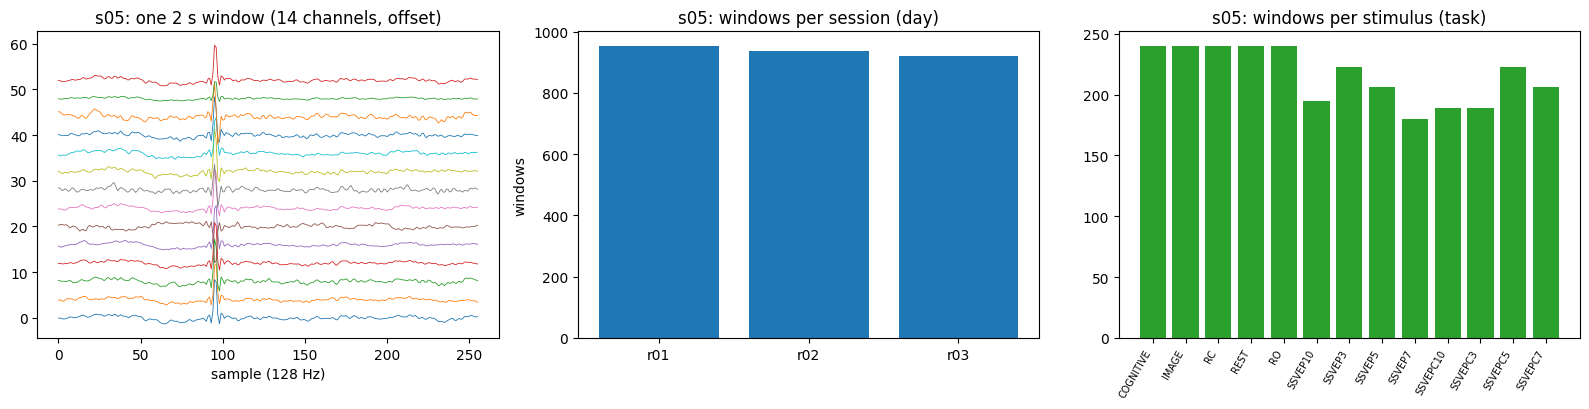

In [7]:
# =====================================================================================
# CELL D — ONE SUBJECT IN FULL DETAIL (self-explanatory). Change PICK to s01..s21.
# Shows: how much data this person has, split by day & task; the ACTUAL numbers in one
#        2 s window; which electrodes carry their signal; quality; and plots.
# =====================================================================================
import glob, os, numpy as np, matplotlib.pyplot as plt
PICK = "s05"                                   # <-- change to any subject id

cache = (sorted(glob.glob("artifacts/cache/*all*128hz*.npz")) or sorted(glob.glob("artifacts/cache/*.npz")))[0]
z = np.load(cache, allow_pickle=True)
X=z["X"]; y=np.asarray(z["y"]).ravel(); names=np.asarray(z["subjects"]).ravel()
session=np.asarray(z["session"]).ravel(); stimulus=np.asarray(z["stimulus"]).ravel()
quality=np.asarray(z["quality"]).ravel(); chans=list(np.asarray(z["channels"]).ravel())
subj = np.array([names[i] for i in y])
m = subj==PICK                                 # boolean mask = only this subject's windows
Xs = X[m]

print("="*78); print(f"SUBJECT {PICK} — FULL DETAIL"); print("="*78)
print(f"This person has {m.sum():,} windows (2 s EEG samples) in total.")
print("Each window is a 14 x 256 matrix = 14 electrodes x 256 time points (2 s @ 128 Hz).\n")

# ---- 1) how the person's data splits across DAYS x TASKS ----
print("-"*78); print("1) WINDOWS per SESSION x STIMULUS  (rows=day, cols=task)")
print("   MEANING: shows this person was recorded across all 3 days and many tasks.")
sess_u, stim_u = sorted(set(session[m])), sorted(set(stimulus[m]))
hdr = "day   " + "".join(f"{s[:7]:>9s}" for s in stim_u) + f"{'TOTAL':>9s}"
print(hdr)
for s in sess_u:
    row=[int(((session==s)&(stimulus==t)&m).sum()) for t in stim_u]
    print(f"{s:>4s}  " + "".join(f"{v:>9,}" for v in row) + f"{sum(row):>9,}")
print()

# ---- 2) the ACTUAL numbers inside ONE window ----
print("-"*78); print("2) ONE EXAMPLE WINDOW — the raw numbers the model sees")
w = Xs[0]                                       # first window of this subject
print(f"   shape = {w.shape} (14 channels x 256 samples)")
print(f"   channel '{chans[0]}', first 12 of 256 values (z-scored units):")
print("   ", np.round(w[0,:12],3))
print(f"   this window: overall mean={w.mean():.3f}, std={w.std():.3f}, min={w.min():.2f}, max={w.max():.2f}")
print("   MEANING: values are z-scored (~0 centred). The model reads 14x256 = 3,584 numbers per window.\n")

# ---- 3) which ELECTRODES carry this person's signal (per-channel stats over ALL their windows) ----
print("-"*78); print("3) PER-ELECTRODE statistics for this subject (across all their windows)")
cm = Xs.mean(axis=(0,2)); cs = Xs.std(axis=(0,2))
for i,ch in enumerate(chans): print(f"   {ch:>4s}: mean={cm[i]:+.3f}  std={cs[i]:.3f}")
print("   MEANING: std per electrode shows how 'active'/variable each location is for this person.\n")

# ---- 4) signal quality for this person ----
qs = quality[m]
print("-"*78); print("4) SIGNAL QUALITY for this subject")
print(f"   min/mean/median = {qs.min():.3f}/{qs.mean():.3f}/{np.median(qs):.3f}; all >=0.35 (kept).")
print("   MEANING: none of this person's windows were dropped as noise/flatline.\n")

# ---- 5) PLOTS: the example window + the per-day / per-task counts ----
fig, ax = plt.subplots(1,3, figsize=(16,4.2))
for c in range(14): ax[0].plot(w[c]+c*4, lw=0.6)
ax[0].set_title(f"{PICK}: one 2 s window (14 channels, offset)"); ax[0].set_xlabel("sample (128 Hz)")
su,sc = np.unique(session[m], return_counts=True); ax[1].bar(su,sc,color="C0")
ax[1].set_title(f"{PICK}: windows per session (day)"); ax[1].set_ylabel("windows")
tu,tc = np.unique(stimulus[m], return_counts=True); ax[2].bar(range(len(tu)),tc,color="C2")
ax[2].set_xticks(range(len(tu))); ax[2].set_xticklabels(tu,rotation=60,ha="right",fontsize=7)
ax[2].set_title(f"{PICK}: windows per stimulus (task)")
plt.tight_layout(); plt.savefig(f"subject_{PICK}_detail.png",dpi=150,bbox_inches="tight")
print(f"[saved] subject_{PICK}_detail.png  -> show this to your supervisor.")

THE MODEL:
  encoder=ecapa  emb_dim=128
  learned params: 398,973
  checkpoint: artifacts/results/ccpm_run1/checkpoints/best.pt

INPUT : (512, 14, 256)  = (B windows, 14 channels, 256 samples)
OUTPUT: (512, 128)  = (B, 128)  <- each window -> one 128-number fingerprint
L2-norms (≈1.0): [1. 1. 1.]
window 0 fingerprint, first 12 of 128: [-0.108 -0.046 -0.033  0.017 -0.156  0.042 -0.102  0.144 -0.151 -0.002
  0.006  0.006]
[saved] step2_embedding_heatmap.png + step2_embeddings_pca.png


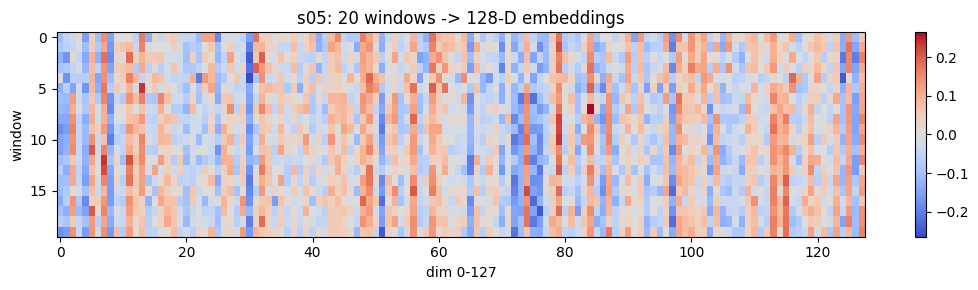

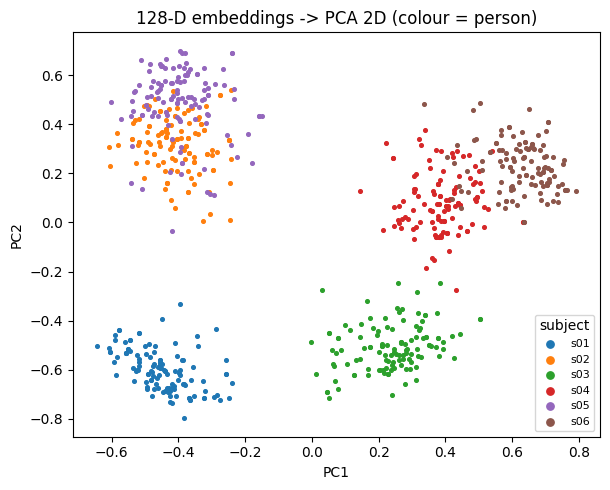

In [8]:
import glob, numpy as np, torch, matplotlib.pyplot as plt
from fed_real_bed.config import load_config
from fed_real_bed.models import EEGAuthenticator
cfg = load_config("configs/brev_gpu_p0_ecapa_ccpm.yaml")
samples = int(round(cfg.raw["data"]["window_sec"]*cfg.raw["data"]["target_sampling_rate"]))
device  = "cuda" if torch.cuda.is_available() else "cpu"
ckpts = sorted(glob.glob("artifacts/results/*ccpm*/checkpoints/best.pt") +
               glob.glob("artifacts/results/m10_ccpm_seed*/checkpoints/best.pt"))
ckpt_path = ckpts[0]
model = EEGAuthenticator(cfg.raw, samples=samples).to(device)
try:    state = torch.load(ckpt_path, map_location=device, weights_only=False)
except TypeError: state = torch.load(ckpt_path, map_location=device)
model.load_state_dict(state["model"] if isinstance(state,dict) and "model" in state else state); model.eval()
print("THE MODEL:"); print(f"  encoder={cfg.raw['model']['encoder']}  emb_dim={cfg.raw['model']['emb_dim']}")
print(f"  learned params: {sum(p.numel() for p in model.parameters()):,}\n  checkpoint: {ckpt_path}\n")
z = np.load(sorted(glob.glob('artifacts/cache/*all*128hz*.npz'))[0], allow_pickle=True)
X=z["X"]; y=np.asarray(z["y"]).ravel(); names=np.asarray(z["subjects"]).ravel(); subj=np.array([names[i] for i in y])
PICK="s05"; idx=np.where(subj==PICK)[0][:512]; xb=torch.tensor(X[idx],dtype=torch.float32,device=device)
print(f"INPUT : {tuple(xb.shape)}  = (B windows, 14 channels, 256 samples)")
with torch.no_grad(): emb,_=model(xb)
emb=emb.cpu().numpy()
print(f"OUTPUT: {emb.shape}  = (B, 128)  <- each window -> one 128-number fingerprint")
print(f"L2-norms (≈1.0): {np.round(np.linalg.norm(emb[:3],axis=1),3)}")
print(f"window 0 fingerprint, first 12 of 128: {np.round(emb[0,:12],3)}")
plt.figure(figsize=(11,3)); plt.imshow(emb[:20],aspect='auto',cmap='coolwarm'); plt.colorbar()
plt.title(f"{PICK}: 20 windows -> 128-D embeddings"); plt.xlabel("dim 0-127"); plt.ylabel("window")
plt.tight_layout(); plt.savefig("step2_embedding_heatmap.png",dpi=150,bbox_inches="tight")
from sklearn.decomposition import PCA
Es=[]; labs=[]
for s in names[:6]:
    si=np.where(subj==s)[0][:120]
    with torch.no_grad(): e,_=model(torch.tensor(X[si],dtype=torch.float32,device=device))
    Es.append(e.cpu().numpy()); labs+=[s]*len(si)
E=np.concatenate(Es); labs=np.array(labs); P=PCA(2).fit_transform(E)
plt.figure(figsize=(6.2,5))
for s in np.unique(labs):
    m=labs==s; plt.scatter(P[m,0],P[m,1],s=7,label=s)
plt.legend(markerscale=2,fontsize=8,title="subject"); plt.title("128-D embeddings -> PCA 2D (colour = person)")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.tight_layout(); plt.savefig("step2_embeddings_pca.png",dpi=150,bbox_inches="tight")
print("[saved] step2_embedding_heatmap.png + step2_embeddings_pca.png")

In [9]:
# STEP 2b — EMBEDDINGS AS A DATABASE TABLE (one row = one window's fingerprint)
import glob, numpy as np, pandas as pd, torch
from fed_real_bed.config import load_config
from fed_real_bed.models import EEGAuthenticator
cfg=load_config("configs/brev_gpu_p0_ecapa_ccpm.yaml")
samples=int(round(cfg.raw["data"]["window_sec"]*cfg.raw["data"]["target_sampling_rate"]))
device="cuda" if torch.cuda.is_available() else "cpu"
ck=sorted(glob.glob("artifacts/results/*ccpm*/checkpoints/best.pt")+
          glob.glob("artifacts/results/m10_ccpm_seed*/checkpoints/best.pt"))[0]
model=EEGAuthenticator(cfg.raw,samples=samples).to(device)
try: st=torch.load(ck,map_location=device,weights_only=False)
except TypeError: st=torch.load(ck,map_location=device)
model.load_state_dict(st["model"] if isinstance(st,dict) and "model" in st else st); model.eval()

z=np.load(sorted(glob.glob("artifacts/cache/*all*128hz*.npz"))[0],allow_pickle=True)
X=z["X"]; y=np.asarray(z["y"]).ravel(); names=np.asarray(z["subjects"]).ravel()
session=np.asarray(z["session"]).ravel(); stimulus=np.asarray(z["stimulus"]).ravel()
quality=np.asarray(z["quality"]).ravel(); subj=np.array([names[i] for i in y])

PICK="s05"                                   # change to any subject (or loop for all)
idx=np.where(subj==PICK)[0]
embs=[]
with torch.no_grad():
    for i in range(0,len(idx),512):
        b=idx[i:i+512]; e,_=model(torch.tensor(X[b],dtype=torch.float32,device=device)); embs.append(e.cpu().numpy())
E=np.concatenate(embs)
meta=pd.DataFrame({"window_id":idx,"subject":subj[idx],"session":session[idx],
                   "stimulus":stimulus[idx],"quality":np.round(quality[idx],3)})
emb_df=pd.DataFrame(E,columns=[f"e{j:03d}" for j in range(E.shape[1])]).round(4)
DB=pd.concat([meta.reset_index(drop=True),emb_df],axis=1)

print(f"EMBEDDING DATABASE for {PICK}: {DB.shape[0]} rows (windows) x {DB.shape[1]} columns")
print(" columns = window_id, subject, session, stimulus, quality, e000..e127 (the 128 fingerprint dims)\n")
prev=DB[["window_id","subject","session","stimulus","quality",
         "e000","e001","e002","e003","e004","e005","e127"]].copy()
prev["L2_norm"]=np.round(np.linalg.norm(E,axis=1),3)
print("PREVIEW (metadata + first 6 dims + last dim + norm):")
print(prev.head(12).to_string(index=False))
DB.to_csv(f"embeddings_{PICK}.csv",index=False)
print(f"\n[saved] embeddings_{PICK}.csv  <- full table, open in Excel ({DB.shape[0]} x {DB.shape[1]})")
DB.head(8)        # renders as a scrollable HTML table in Jupyter

EMBEDDING DATABASE for s05: 2811 rows (windows) x 133 columns
 columns = window_id, subject, session, stimulus, quality, e000..e127 (the 128 fingerprint dims)

PREVIEW (metadata + first 6 dims + last dim + norm):
 window_id subject session stimulus  quality    e000    e001    e002    e003    e004   e005   e127  L2_norm
     10871     s05     r01    IMAGE      1.0 -0.1084 -0.0459 -0.0328  0.0170 -0.1559 0.0417 0.0583      1.0
     10872     s05     r01    IMAGE      1.0 -0.0820 -0.0589 -0.0432 -0.0049 -0.1052 0.0522 0.1096      1.0
     10873     s05     r01    IMAGE      1.0 -0.1239 -0.1717  0.0243 -0.0408 -0.1403 0.0995 0.1619      1.0
     10874     s05     r01    IMAGE      1.0 -0.0917 -0.0799 -0.0481 -0.0159 -0.1181 0.0820 0.1080      1.0
     10875     s05     r01    IMAGE      1.0 -0.0134 -0.1751 -0.0594 -0.0685 -0.0723 0.0911 0.0827      1.0
     10876     s05     r01    IMAGE      1.0 -0.1319 -0.0661 -0.1478 -0.0156 -0.1710 0.0906 0.1050      1.0
     10877     s05     r01    I

,window_id,subject,session,stimulus,quality,e000,e001,e002,e003,e004,...,e118,e119,e120,e121,e122,e123,e124,e125,e126,e127
0,10871,s05,r01,IMAGE,1.0,-0.1084,-0.0459,-0.0328,0.0170,-0.1559,...,-0.0091,0.0194,0.0728,0.0459,-0.0251,0.0489,-0.1383,0.1328,-0.1042,0.0583
1,10872,s05,r01,IMAGE,1.0,-0.0820,-0.0589,-0.0432,-0.0049,-0.1052,...,0.0089,0.0588,0.0845,0.0546,-0.0580,0.0688,-0.1388,0.1799,-0.1456,0.1096
2,10873,s05,r01,IMAGE,1.0,-0.1239,-0.1717,0.0243,-0.0408,-0.1403,...,-0.0490,-0.0041,0.0577,-0.0665,0.0189,0.0371,-0.2087,0.1572,-0.2031,0.1619
3,10874,s05,r01,IMAGE,1.0,-0.0917,-0.0799,-0.0481,-0.0159,-0.1181,...,0.0404,0.0253,0.0808,0.0260,-0.0498,0.0608,-0.1464,0.1552,-0.1483,0.1080
4,10875,s05,r01,IMAGE,1.0,-0.0134,-0.1751,-0.0594,-0.0685,-0.0723,...,-0.0805,-0.0070,0.1198,-0.0720,0.0361,0.0487,-0.2453,0.0185,-0.1246,0.0827
5,10876,s05,r01,IMAGE,1.0,-0.1319,-0.0661,-0.1478,-0.0156,-0.1710,...,-0.0824,0.0264,0.0302,-0.0000,-0.0493,0.0287,-0.1292,0.0927,-0.0825,0.1050
6,10877,s05,r01,IMAGE,1.0,-0.1021,-0.1140,0.1253,-0.0191,-0.0877,...,-0.0323,0.0380,0.0425,-0.0567,0.0278,0.1099,-0.0952,0.0824,-0.1558,0.1142
7,10878,s05,r01,IMAGE,1.0,-0.1147,-0.1229,0.0996,-0.0021,-0.0842,...,0.0322,0.0993,-0.0487,0.0004,-0.0461,0.0013,-0.0976,0.1362,-0.1421,0.1132


In [10]:
# STEP 2c — EXPORT ONE SUBJECT TO AN EXCEL WORKBOOK (database-style, multi-sheet)
import glob, numpy as np, pandas as pd, torch
try: import openpyxl
except ImportError:
    import subprocess,sys; subprocess.run([sys.executable,"-m","pip","install","-q","openpyxl"])
from fed_real_bed.config import load_config
from fed_real_bed.models import EEGAuthenticator

cfg=load_config("configs/brev_gpu_p0_ecapa_ccpm.yaml")
samples=int(round(cfg.raw["data"]["window_sec"]*cfg.raw["data"]["target_sampling_rate"]))
device="cuda" if torch.cuda.is_available() else "cpu"
ck=sorted(glob.glob("artifacts/results/*ccpm*/checkpoints/best.pt")+
          glob.glob("artifacts/results/m10_ccpm_seed*/checkpoints/best.pt"))[0]
model=EEGAuthenticator(cfg.raw,samples=samples).to(device)
try: st=torch.load(ck,map_location=device,weights_only=False)
except TypeError: st=torch.load(ck,map_location=device)
model.load_state_dict(st["model"] if isinstance(st,dict) and "model" in st else st); model.eval()

z=np.load(sorted(glob.glob("artifacts/cache/*all*128hz*.npz"))[0],allow_pickle=True)
X=z["X"]; y=np.asarray(z["y"]).ravel(); names=np.asarray(z["subjects"]).ravel()
session=np.asarray(z["session"]).ravel(); stimulus=np.asarray(z["stimulus"]).ravel()
quality=np.asarray(z["quality"]).ravel(); chans=list(np.asarray(z["channels"]).ravel())
subj=np.array([names[i] for i in y])

PICK="s05"; idx=np.where(subj==PICK)[0]
embs=[]
with torch.no_grad():
    for i in range(0,len(idx),512):
        b=idx[i:i+512]; e,_=model(torch.tensor(X[b],dtype=torch.float32,device=device)); embs.append(e.cpu().numpy())
E=np.concatenate(embs)
meta=pd.DataFrame({"window_id":idx,"subject":subj[idx],"session":session[idx],
                   "stimulus":stimulus[idx],"quality":np.round(quality[idx],3)})
DB=pd.concat([meta.reset_index(drop=True),
              pd.DataFrame(E,columns=[f"e{j:03d}" for j in range(E.shape[1])]).round(4)],axis=1)

# extra sheets
counts=meta.pivot_table(index="session",columns="stimulus",values="window_id",aggfunc="count",fill_value=0)
raw0=pd.DataFrame(np.round(X[idx[0]],3),index=chans,
                  columns=[f"t{j:03d}" for j in range(X.shape[2])])   # one window: 14 channels x 256 samples
info=pd.DataFrame({"field":["subject","total_windows","window_shape","embedding_dim","sheets"],
   "value":[PICK,len(idx),"14 channels x 256 samples (2 s @128Hz)",E.shape[1],
            "windows_embeddings | counts_session_stimulus | one_window_raw_14x256"]})

out=f"subject_{PICK}_workbook.xlsx"
with pd.ExcelWriter(out, engine="openpyxl") as xl:
    info.to_excel(xl,sheet_name="README",index=False)
    DB.to_excel(xl,sheet_name="windows_embeddings",index=False)
    counts.to_excel(xl,sheet_name="counts_session_stimulus")
    raw0.to_excel(xl,sheet_name="one_window_raw_14x256")
print(f"[saved] {out}")
print(f"  Sheet 'windows_embeddings' : {DB.shape[0]} rows x {DB.shape[1]} cols (every window + its 128-D fingerprint)")
print(f"  Sheet 'counts_session_stimulus' : windows per day x task")
print(f"  Sheet 'one_window_raw_14x256' : the actual 14x256 raw values of one window")
print("Download this .xlsx from the Jupyter file browser and open in Excel.")

[saved] subject_s05_workbook.xlsx
  Sheet 'windows_embeddings' : 2811 rows x 133 cols (every window + its 128-D fingerprint)
  Sheet 'counts_session_stimulus' : windows per day x task
  Sheet 'one_window_raw_14x256' : the actual 14x256 raw values of one window
Download this .xlsx from the Jupyter file browser and open in Excel.


In [11]:
# STEP 2d — INTERNAL TRACE: one window through EVERY layer, with exact values
import glob, numpy as np, torch
from fed_real_bed.config import load_config
from fed_real_bed.models import EEGAuthenticator
from fed_real_bed.utils import torch_l2_normalize
cfg=load_config("configs/brev_gpu_p0_ecapa_ccpm.yaml")
samples=int(round(cfg.raw["data"]["window_sec"]*cfg.raw["data"]["target_sampling_rate"]))
device="cuda" if torch.cuda.is_available() else "cpu"
ck=sorted(glob.glob("artifacts/results/*ccpm*/checkpoints/best.pt")+
          glob.glob("artifacts/results/m10_ccpm_seed*/checkpoints/best.pt"))[0]
model=EEGAuthenticator(cfg.raw,samples=samples).to(device)
try: st=torch.load(ck,map_location=device,weights_only=False)
except TypeError: st=torch.load(ck,map_location=device)
model.load_state_dict(st["model"] if isinstance(st,dict) and "model" in st else st); model.eval()
enc=model.encoder

z=np.load(sorted(glob.glob("artifacts/cache/*all*128hz*.npz"))[0],allow_pickle=True)
X=z["X"]; y=np.asarray(z["y"]).ravel(); names=np.asarray(z["subjects"]).ravel(); subj=np.array([names[i] for i in y])
i0=int(np.where(subj=="s05")[0][0])
x=torch.tensor(X[i0:i0+1],dtype=torch.float32,device=device)   # ONE window (1,14,256)

def show(name,t):
    f=t.detach().cpu().numpy().ravel()
    print(f"{name:34s} shape={tuple(t.shape)}  first5={np.round(f[:5],3)}  mean={f.mean():+.3f} std={f.std():.3f}")

print("="*92); print("INTERNAL FORWARD TRACE — subject s05, window",i0); print("="*92)
with torch.no_grad():
    show("0 INPUT window", x)
    h =enc.stem(x);                              show("1 stem  Conv(14->128,k5)+skip", h)
    h1=enc.b1(h);                                show("2 b1    Conv(k3,dil2)+SE",       h1)
    h2=enc.b2(h1);                               show("3 b2    Conv(k3,dil3)+SE",       h2)
    h3=enc.b3(h2);                               show("4 b3    Conv(k3,dil4)+SE",       h3)
    zt=enc.mix(torch.cat([h1,h2,h3],1));         show("5 mix   fuse 3 scales (384->128)",zt)
    a =enc.attn(zt);                             show("6 attn  weights (sum over time=%.3f)"%a.sum().item(), a)
    mean=(zt*a).sum(-1);                         show("7 weighted MEAN over time",       mean)
    std=torch.sqrt(((zt-mean.unsqueeze(-1))**2*a).sum(-1).clamp_min(1e-6)); show("8 weighted STD over time", std)
    pooled=torch.cat([mean,std],1);             show("9 concat [mean|std]",              pooled)
    proj=enc.proj(pooled);                       show("10 proj  Linear(256->128)+LayerNorm",proj)
    emb=torch_l2_normalize(proj);                show("11 FINAL embedding (L2-norm)",     emb)
    print(f"\nfinal embedding length (||emb||) = {emb.norm().item():.4f}  (=1.0 -> unit sphere, cosine-ready)")
    print("first 12 of the 128 numbers:", np.round(emb.cpu().numpy().ravel()[:12],3))
print("\nNOTE: the 128 numbers in step 11 are produced TOGETHER by the Linear layer in step 10 —")
print("each output = a learned weighted sum of all 256 pooled features (not generated one-by-one).")

INTERNAL FORWARD TRACE — subject s05, window 10871
0 INPUT window                     shape=(1, 14, 256)  first5=[-0.014 -0.051 -0.155 -0.234 -0.21 ]  mean=+0.022 std=0.802
1 stem  Conv(14->128,k5)+skip      shape=(1, 160, 256)  first5=[0.35  0.281 0.241 0.139 0.175]  mean=+0.032 std=0.828
2 b1    Conv(k3,dil2)+SE           shape=(1, 160, 256)  first5=[0.599 0.545 0.812 0.673 0.626]  mean=+0.072 std=0.581
3 b2    Conv(k3,dil3)+SE           shape=(1, 160, 256)  first5=[0.124 0.16  0.18  0.065 0.184]  mean=+0.102 std=0.522
4 b3    Conv(k3,dil4)+SE           shape=(1, 160, 256)  first5=[0.339 0.113 0.143 0.179 0.311]  mean=+0.126 std=0.649
5 mix   fuse 3 scales (384->128)   shape=(1, 160, 256)  first5=[-0.09  -0.024 -0.096  0.252  0.528]  mean=+0.012 std=0.474
6 attn  weights (sum over time=1.000) shape=(1, 1, 256)  first5=[0.003 0.005 0.007 0.004 0.003]  mean=+0.004 std=0.002
7 weighted MEAN over time          shape=(1, 160)  first5=[-0.007  0.023  0.004 -0.003 -0.025]  mean=+0.002 std=0

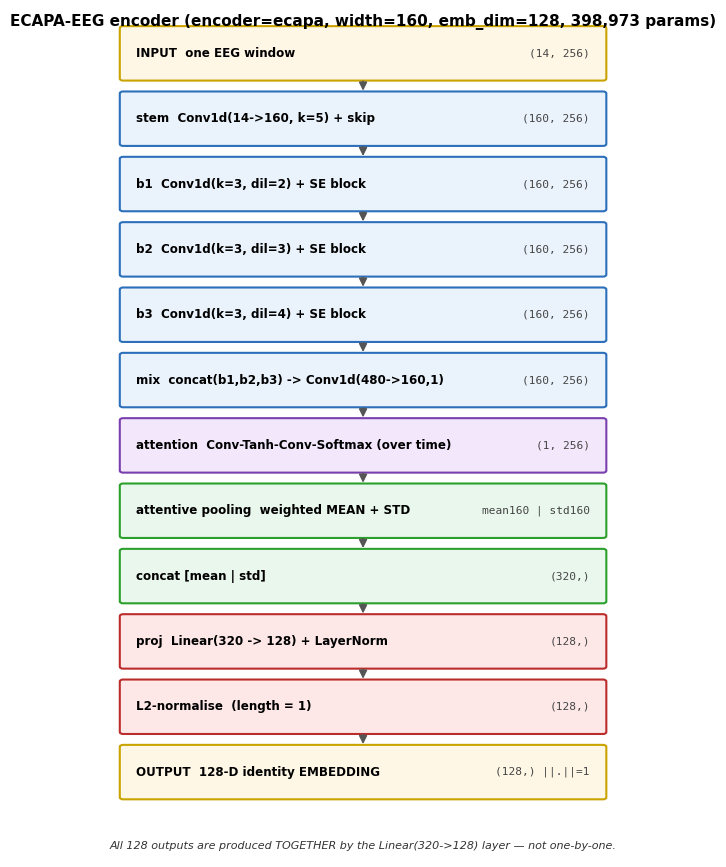

[saved] ecapa_architecture.png


In [12]:
# ECAPA-EEG ARCHITECTURE DIAGRAM (draws the block diagram, saves a PNG)
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
fig,ax=plt.subplots(figsize=(8.6,11)); ax.axis("off"); ax.set_xlim(0,10); ax.set_ylim(0,21)
def box(y,txt,shape,c,e,h=1.25,x=1.4,w=7.2):
    ax.add_patch(FancyBboxPatch((x,y),w,h,boxstyle="round,pad=0.05",fc=c,ec=e,lw=1.5))
    ax.text(x+0.2,y+h/2,txt,ha="left",va="center",fontsize=8.6,fontweight="bold")
    ax.text(x+w-0.2,y+h/2,shape,ha="right",va="center",fontsize=8,family="monospace",color="#444")
def arr(y0,y1): ax.add_patch(FancyArrowPatch((5,y0),(5,y1),arrowstyle="-|>",mutation_scale=12,color="#555",lw=1.2))
rows=[
 ("INPUT  one EEG window","(14, 256)","#fff7e6","#caa300"),
 ("stem  Conv1d(14->160, k=5) + skip","(160, 256)","#eaf2fb","#2c6fbb"),
 ("b1  Conv1d(k=3, dil=2) + SE block","(160, 256)","#eaf2fb","#2c6fbb"),
 ("b2  Conv1d(k=3, dil=3) + SE block","(160, 256)","#eaf2fb","#2c6fbb"),
 ("b3  Conv1d(k=3, dil=4) + SE block","(160, 256)","#eaf2fb","#2c6fbb"),
 ("mix  concat(b1,b2,b3) -> Conv1d(480->160,1)","(160, 256)","#eaf2fb","#2c6fbb"),
 ("attention  Conv-Tanh-Conv-Softmax (over time)","(1, 256)","#f3e8fb","#7a3fae"),
 ("attentive pooling  weighted MEAN + STD","mean160 | std160","#e9f7ec","#2ca02c"),
 ("concat [mean | std]","(320,)","#e9f7ec","#2ca02c"),
 ("proj  Linear(320 -> 128) + LayerNorm","(128,)","#fde7e7","#bb2c2c"),
 ("L2-normalise  (length = 1)","(128,)","#fde7e7","#bb2c2c"),
 ("OUTPUT  128-D identity EMBEDDING","(128,) ||.||=1","#fff7e6","#caa300"),
]
Y=19.3; step=1.62; ys=[]
for i,(t,s,c,e) in enumerate(rows):
    y=Y-i*step; ys.append(y); box(y,t,s,c,e)
for i in range(len(ys)-1): arr(ys[i], ys[i+1]+1.25)
ax.text(5,20.6,"ECAPA-EEG encoder (encoder=ecapa, width=160, emb_dim=128, 398,973 params)",
        ha="center",fontsize=11,fontweight="bold")
ax.text(5,0.2,"All 128 outputs are produced TOGETHER by the Linear(320->128) layer — not one-by-one.",
        ha="center",fontsize=8,style="italic",color="#333")
plt.savefig("ecapa_architecture.png",dpi=200,bbox_inches="tight"); plt.show()
print("[saved] ecapa_architecture.png")

In [ ]:
I deliberately chose a strong, standard, well-understood encoder so my contribution — the CCPM scoring rule — can be cleanly isolated and fairly measured. If I'd invented a new encoder, I couldn't attribute the improvement to my scoring method. ECAPA is specifically a verification architecture (state-of-the-art in speaker verification, which is the same open-set accept/reject task as biometrics); its attentive statistics pooling is ideal for noisy, variable consumer EEG because it learns which time segments matter; its multi-scale dilated convolutions capture EEG rhythms at several time scales; and at ~0.4 M parameters it's compact enough not to overfit a 21-subject dataset. So the encoder is a sound, reproducible backbone — and the novelty lives at the scoring stage (CCPM), exactly where I claim it."

In one line: "Standard encoder by design, so the novelty (CCPM) is isolated and the comparison is fair."

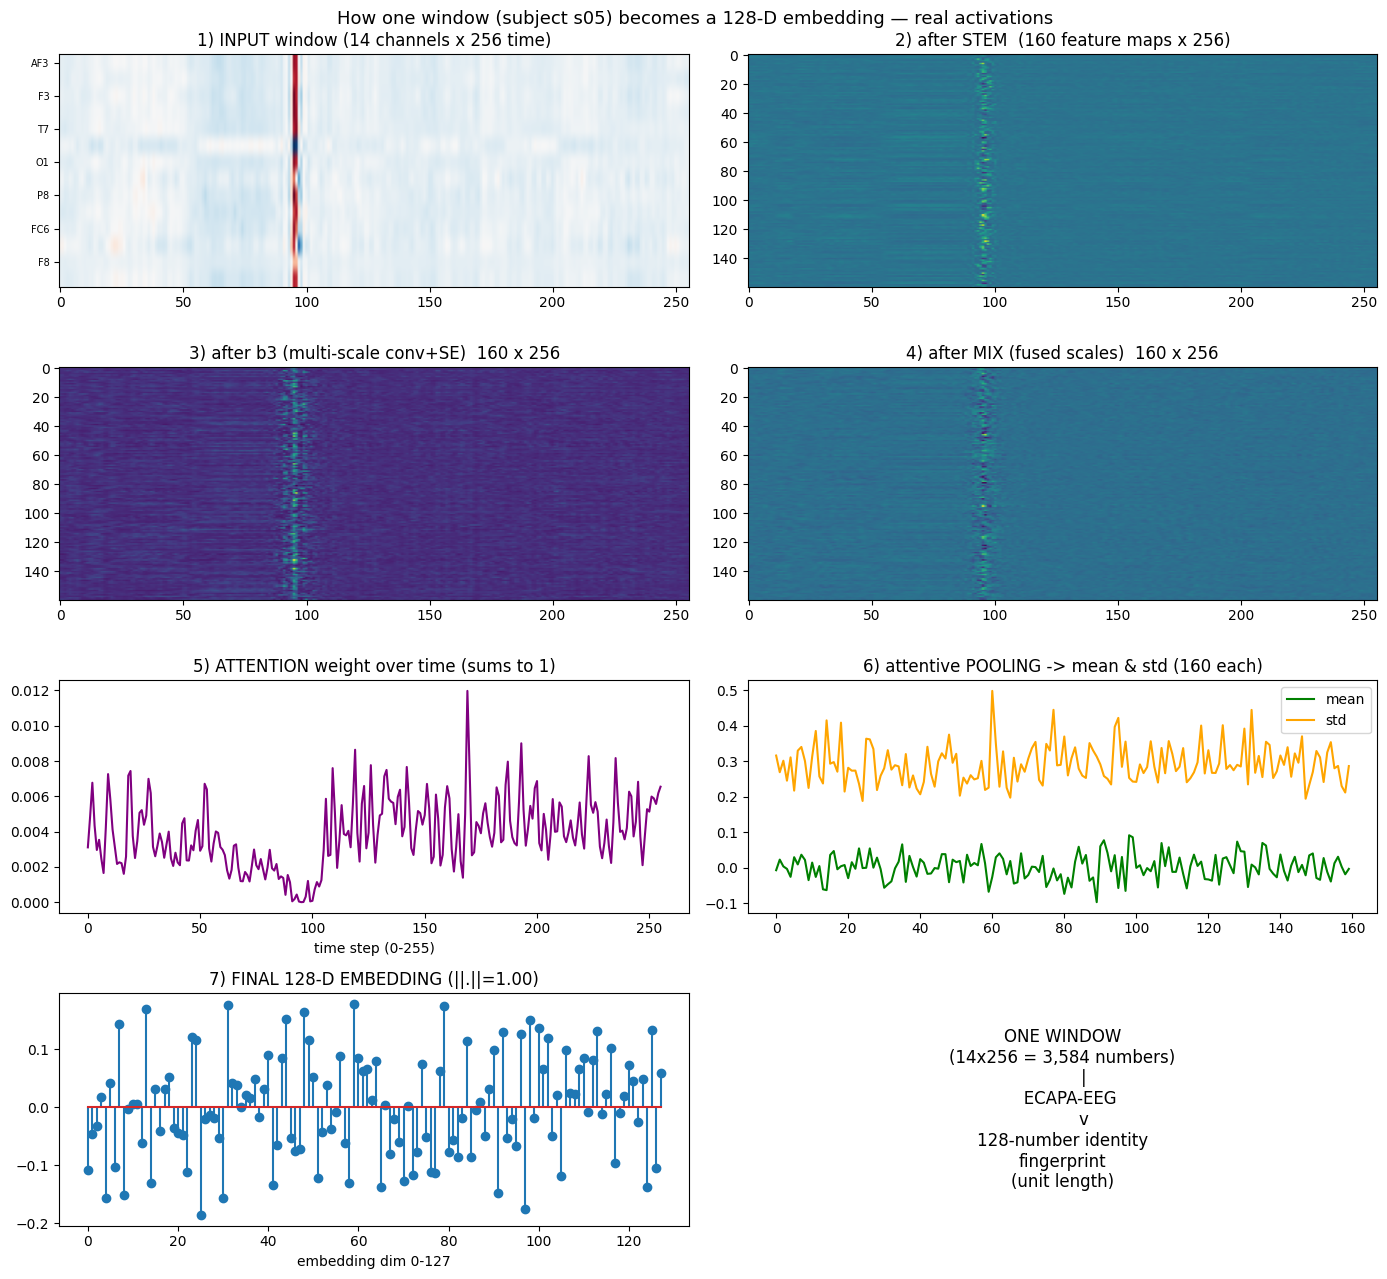

[saved] ecapa_per_layer_activations.png


In [13]:
# REAL PER-LAYER ACTIVATIONS — one window through ECAPA-EEG, plotted at each stage
import glob, numpy as np, torch, matplotlib.pyplot as plt
from fed_real_bed.config import load_config
from fed_real_bed.models import EEGAuthenticator
from fed_real_bed.utils import torch_l2_normalize
cfg=load_config("configs/brev_gpu_p0_ecapa_ccpm.yaml")
samples=int(round(cfg.raw["data"]["window_sec"]*cfg.raw["data"]["target_sampling_rate"]))
device="cuda" if torch.cuda.is_available() else "cpu"
ck=sorted(glob.glob("artifacts/results/*ccpm*/checkpoints/best.pt")+
          glob.glob("artifacts/results/m10_ccpm_seed*/checkpoints/best.pt"))[0]
model=EEGAuthenticator(cfg.raw,samples=samples).to(device)
try: st=torch.load(ck,map_location=device,weights_only=False)
except TypeError: st=torch.load(ck,map_location=device)
model.load_state_dict(st["model"] if isinstance(st,dict) and "model" in st else st); model.eval()
enc=model.encoder

z=np.load(sorted(glob.glob("artifacts/cache/*all*128hz*.npz"))[0],allow_pickle=True)
X=z["X"]; y=np.asarray(z["y"]).ravel(); names=np.asarray(z["subjects"]).ravel(); subj=np.array([names[i] for i in y])
chans=list(np.asarray(z["channels"]).ravel())
i0=int(np.where(subj=="s05")[0][0])
x=torch.tensor(X[i0:i0+1],dtype=torch.float32,device=device)
with torch.no_grad():
    h=enc.stem(x); h1=enc.b1(h); h2=enc.b2(h1); h3=enc.b3(h2)
    zt=enc.mix(torch.cat([h1,h2,h3],1)); a=enc.attn(zt)
    mean=(zt*a).sum(-1); std=torch.sqrt(((zt-mean.unsqueeze(-1))**2*a).sum(-1).clamp_min(1e-6))
    pooled=torch.cat([mean,std],1); proj=enc.proj(pooled); emb=torch_l2_normalize(proj)
def n(t): return t.detach().cpu().numpy()
fig,ax=plt.subplots(4,2,figsize=(14,13))
ax[0,0].imshow(n(x)[0],aspect="auto",cmap="RdBu_r"); ax[0,0].set_title("1) INPUT window (14 channels x 256 time)"); ax[0,0].set_yticks(range(0,14,2)); ax[0,0].set_yticklabels([chans[i] for i in range(0,14,2)],fontsize=7)
ax[0,1].imshow(n(h)[0],aspect="auto",cmap="viridis"); ax[0,1].set_title("2) after STEM  (160 feature maps x 256)")
ax[1,0].imshow(n(h3)[0],aspect="auto",cmap="viridis"); ax[1,0].set_title("3) after b3 (multi-scale conv+SE)  160 x 256")
ax[1,1].imshow(n(zt)[0],aspect="auto",cmap="viridis"); ax[1,1].set_title("4) after MIX (fused scales)  160 x 256")
ax[2,0].plot(n(a)[0,0],color="purple"); ax[2,0].set_title("5) ATTENTION weight over time (sums to 1)"); ax[2,0].set_xlabel("time step (0-255)")
ax[2,1].plot(n(mean)[0],label="mean",color="green"); ax[2,1].plot(n(std)[0],label="std",color="orange"); ax[2,1].legend(); ax[2,1].set_title("6) attentive POOLING -> mean & std (160 each)")
ax[3,0].stem(n(emb)[0]); ax[3,0].set_title(f"7) FINAL 128-D EMBEDDING (||.||={np.linalg.norm(n(emb)):.2f})"); ax[3,0].set_xlabel("embedding dim 0-127")
ax[3,1].axis("off"); ax[3,1].text(0.5,0.5,"ONE WINDOW\n(14x256 = 3,584 numbers)\n        |\n   ECAPA-EEG\n        v\n128-number identity\nfingerprint\n(unit length)",ha="center",va="center",fontsize=12)
fig.suptitle(f"How one window (subject s05) becomes a 128-D embedding — real activations",fontsize=13)
fig.tight_layout(); fig.savefig("ecapa_per_layer_activations.png",dpi=140,bbox_inches="tight"); plt.show()
print("[saved] ecapa_per_layer_activations.png")

In [14]:
# MATHEMATICAL VERIFICATION of each layer + EXPORT all internal values to Excel
import glob, numpy as np, torch, pandas as pd
from fed_real_bed.config import load_config
from fed_real_bed.models import EEGAuthenticator
from fed_real_bed.utils import torch_l2_normalize
cfg=load_config("configs/brev_gpu_p0_ecapa_ccpm.yaml")
samples=int(round(cfg.raw["data"]["window_sec"]*cfg.raw["data"]["target_sampling_rate"]))
device="cuda" if torch.cuda.is_available() else "cpu"
ck=sorted(glob.glob("artifacts/results/*ccpm*/checkpoints/best.pt")+
          glob.glob("artifacts/results/m10_ccpm_seed*/checkpoints/best.pt"))[0]
model=EEGAuthenticator(cfg.raw,samples=samples).to(device)
try: st=torch.load(ck,map_location=device,weights_only=False)
except TypeError: st=torch.load(ck,map_location=device)
model.load_state_dict(st["model"] if isinstance(st,dict) and "model" in st else st); model.eval()
enc=model.encoder
z=np.load(sorted(glob.glob("artifacts/cache/*all*128hz*.npz"))[0],allow_pickle=True)
X=z["X"]; y=np.asarray(z["y"]).ravel(); names=np.asarray(z["subjects"]).ravel(); subj=np.array([names[i] for i in y])
i0=int(np.where(subj=="s05")[0][0]); x=torch.tensor(X[i0:i0+1],dtype=torch.float32,device=device)

with torch.no_grad():
    h=enc.stem(x); h1=enc.b1(h); h2=enc.b2(h1); h3=enc.b3(h2)
    zt=enc.mix(torch.cat([h1,h2,h3],1)); a=enc.attn(zt)
    mean=(zt*a).sum(-1); std=torch.sqrt(((zt-mean.unsqueeze(-1))**2*a).sum(-1).clamp_min(1e-6))
    pooled=torch.cat([mean,std],1); lin=enc.proj[0]; ln=enc.proj[1]
    proj=enc.proj(pooled); emb=torch_l2_normalize(proj)
Z=zt[0].cpu().numpy(); A=a[0,0].cpu().numpy()                 # (160,256),(256,)
P=pooled[0].cpu().numpy(); PR=proj[0].cpu().numpy(); EM=emb[0].cpu().numpy()

print("="*74); print("MATHEMATICAL VERIFICATION (NumPy recompute vs network)"); print("="*74)
chk=[]
def rep(name, diff_or_val, ok): chk.append([name,f"{diff_or_val:.2e}","PASS" if ok else "FAIL"]); print(f"  {name:46s} {('%.2e'%diff_or_val):>10s}  {'PASS' if ok else 'FAIL'}")
s=A.sum();                                   rep("[1] sum(attention) == 1", abs(s-1), abs(s-1)<1e-4)
mean_np=Z@A; d=np.abs(mean_np-mean[0].cpu().numpy()).max(); rep("[2] mean == Sum(z*a)", d, d<1e-4)
std_np=np.sqrt(np.maximum(((Z-mean_np[:,None])**2*A).sum(1),1e-6)); d=np.abs(std_np-std[0].cpu().numpy()).max(); rep("[3] std == sqrt(Sum((z-mean)^2*a))", d, d<1e-4)
y_lin=lin.weight.cpu().numpy()@P+lin.bias.cpu().numpy(); d=np.abs(y_lin-lin(pooled)[0].cpu().numpy()).max(); rep("[4] Linear == W*x+b", d, d<1e-4)
m=y_lin.mean(); v=y_lin.var(); ln_np=(y_lin-m)/np.sqrt(v+1e-5)*ln.weight.cpu().numpy()+ln.bias.cpu().numpy(); d=np.abs(ln_np-PR).max(); rep("[5] LayerNorm formula", d, d<1e-3)
nrm=np.linalg.norm(EM);                      rep("[6] ||embedding|| == 1", abs(nrm-1), abs(nrm-1)<1e-4)
e_np=PR/np.linalg.norm(PR); d=np.abs(e_np-EM).max(); rep("[7] embedding == proj/||proj||", d, d<1e-4)
print(f"\nALL PASS = {all(r[2]=='PASS' for r in chk)}  -> the network does EXACTLY the documented math.\n")

with pd.ExcelWriter("s05_window_internal_values.xlsx") as xl:
    pd.DataFrame(chk,columns=["check","max_diff_or_value","result"]).to_excel(xl,"VERIFICATION",index=False)
    pd.DataFrame({"time_step":range(256),"attention_weight":np.round(A,6)}).to_excel(xl,"attention_256",index=False)
    pd.DataFrame({"feature":range(160),"weighted_mean":np.round(mean[0].cpu().numpy(),5),
                  "weighted_std":np.round(std[0].cpu().numpy(),5)}).to_excel(xl,"pooling_160",index=False)
    pd.DataFrame({"dim":range(128),"proj_preL2":np.round(PR,5),"embedding":np.round(EM,5)}).to_excel(xl,"embedding_128",index=False)
print("[saved] s05_window_internal_values.xlsx  (4 sheets: VERIFICATION, attention_256, pooling_160, embedding_128)")

MATHEMATICAL VERIFICATION (NumPy recompute vs network)
  [1] sum(attention) == 1                          0.00e+00  PASS
  [2] mean == Sum(z*a)                             1.49e-08  PASS
  [3] std == sqrt(Sum((z-mean)^2*a))               2.98e-08  PASS


RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

In [15]:
# MATHEMATICAL VERIFICATION (fixed: detach params) + EXPORT internal values to Excel
import glob, numpy as np, torch, pandas as pd
from fed_real_bed.config import load_config
from fed_real_bed.models import EEGAuthenticator
from fed_real_bed.utils import torch_l2_normalize
cfg=load_config("configs/brev_gpu_p0_ecapa_ccpm.yaml")
samples=int(round(cfg.raw["data"]["window_sec"]*cfg.raw["data"]["target_sampling_rate"]))
device="cuda" if torch.cuda.is_available() else "cpu"
ck=sorted(glob.glob("artifacts/results/*ccpm*/checkpoints/best.pt")+
          glob.glob("artifacts/results/m10_ccpm_seed*/checkpoints/best.pt"))[0]
model=EEGAuthenticator(cfg.raw,samples=samples).to(device)
try: st=torch.load(ck,map_location=device,weights_only=False)
except TypeError: st=torch.load(ck,map_location=device)
model.load_state_dict(st["model"] if isinstance(st,dict) and "model" in st else st); model.eval()
enc=model.encoder
npy=lambda t: t.detach().cpu().numpy()            # <-- the fix: detach before numpy
z=np.load(sorted(glob.glob("artifacts/cache/*all*128hz*.npz"))[0],allow_pickle=True)
X=z["X"]; y=np.asarray(z["y"]).ravel(); names=np.asarray(z["subjects"]).ravel(); subj=np.array([names[i] for i in y])
i0=int(np.where(subj=="s05")[0][0]); x=torch.tensor(X[i0:i0+1],dtype=torch.float32,device=device)

with torch.no_grad():
    h=enc.stem(x); h1=enc.b1(h); h2=enc.b2(h1); h3=enc.b3(h2)
    zt=enc.mix(torch.cat([h1,h2,h3],1)); a=enc.attn(zt)
    mean=(zt*a).sum(-1); std=torch.sqrt(((zt-mean.unsqueeze(-1))**2*a).sum(-1).clamp_min(1e-6))
    pooled=torch.cat([mean,std],1); lin=enc.proj[0]; ln=enc.proj[1]
    proj=enc.proj(pooled); emb=torch_l2_normalize(proj)
Z=npy(zt)[0]; A=npy(a)[0,0]; P=npy(pooled)[0]; PR=npy(proj)[0]; EM=npy(emb)[0]
MEAN=npy(mean)[0]; STD=npy(std)[0]
W=npy(lin.weight); B=npy(lin.bias); G=npy(ln.weight); BE=npy(ln.bias)

print("="*72); print("MATHEMATICAL VERIFICATION (NumPy recompute vs network)"); print("="*72)
chk=[]
def rep(n,d,ok): chk.append([n,f"{d:.2e}","PASS" if ok else "FAIL"]); print(f"  {n:44s} {('%.2e'%d):>10s}  {'PASS' if ok else 'FAIL'}")
rep("[1] sum(attention)==1", abs(A.sum()-1), abs(A.sum()-1)<1e-4)
mean_np=Z@A; rep("[2] mean==Sum(z*a)", np.abs(mean_np-MEAN).max(), np.abs(mean_np-MEAN).max()<1e-4)
std_np=np.sqrt(np.maximum(((Z-mean_np[:,None])**2*A).sum(1),1e-6)); rep("[3] std==sqrt(Sum((z-mean)^2*a))", np.abs(std_np-STD).max(), np.abs(std_np-STD).max()<1e-4)
y_lin=W@P+B; rep("[4] Linear==W*x+b", np.abs(y_lin-npy(lin(pooled))[0]).max(), np.abs(y_lin-npy(lin(pooled))[0]).max()<1e-4)
m=y_lin.mean(); v=y_lin.var(); ln_np=(y_lin-m)/np.sqrt(v+1e-5)*G+BE; rep("[5] LayerNorm formula", np.abs(ln_np-PR).max(), np.abs(ln_np-PR).max()<1e-3)
rep("[6] ||embedding||==1", abs(np.linalg.norm(EM)-1), abs(np.linalg.norm(EM)-1)<1e-4)
e_np=PR/np.linalg.norm(PR); rep("[7] embedding==proj/||proj||", np.abs(e_np-EM).max(), np.abs(e_np-EM).max()<1e-4)
print(f"\nALL PASS = {all(r[2]=='PASS' for r in chk)}  -> network does EXACTLY the documented math.\n")

with pd.ExcelWriter("s05_window_internal_values.xlsx") as xl:
    pd.DataFrame(chk,columns=["check","max_diff_or_value","result"]).to_excel(xl,"VERIFICATION",index=False)
    pd.DataFrame({"time_step":range(256),"attention_weight":np.round(A,6)}).to_excel(xl,"attention_256",index=False)
    pd.DataFrame({"feature":range(160),"weighted_mean":np.round(MEAN,5),"weighted_std":np.round(STD,5)}).to_excel(xl,"pooling_160",index=False)
    pd.DataFrame({"dim":range(128),"proj_preL2":np.round(PR,5),"embedding":np.round(EM,5)}).to_excel(xl,"embedding_128",index=False)
print("[saved] s05_window_internal_values.xlsx  (VERIFICATION, attention_256, pooling_160, embedding_128)")

MATHEMATICAL VERIFICATION (NumPy recompute vs network)
  [1] sum(attention)==1                          0.00e+00  PASS
  [2] mean==Sum(z*a)                             1.49e-08  PASS
  [3] std==sqrt(Sum((z-mean)^2*a))               2.98e-08  PASS
  [4] Linear==W*x+b                              4.10e-08  PASS
  [5] LayerNorm formula                          1.67e-06  PASS
  [6] ||embedding||==1                           5.96e-08  PASS
  [7] embedding==proj/||proj||                   0.00e+00  PASS

ALL PASS = True  -> network does EXACTLY the documented math.

[saved] s05_window_internal_values.xlsx  (VERIFICATION, attention_256, pooling_160, embedding_128)


/tmp/ipykernel_358324/3698905060.py:44: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  pd.DataFrame(chk,columns=["check","max_diff_or_value","result"]).to_excel(xl,"VERIFICATION",index=False)
/tmp/ipykernel_358324/3698905060.py:45: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  pd.DataFrame({"time_step":range(256),"attention_weight":np.round(A,6)}).to_excel(xl,"attention_256",index=False)
/tmp/ipykernel_358324/3698905060.py:46: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  pd.DataFrame({"feature":range(160),"weighted_mean":np.round(MEAN,5),"weighted_std":np.round(STD,5)}).to_excel(xl,"pooling_160",index=False)
/tmp/ipykernel_358324/3698905060.py:47: FutureWarning: Starting with pandas version 3.0 all arguments of to_exc

ENROLMENT for s05: 1891 embeddings from sessions r01+r02 (the data we 'register').

k-means made K=3 PROTOTYPES (the stored template for s05).
  prototype 0: built from 358 embeddings
  prototype 1: built from 637 embeddings
  prototype 2: built from 896 embeddings

Each prototype is a 128-D vector. 21 subjects x 3 = 63 prototypes total in the system.

PROTOTYPE TABLE (first 8 of 128 dims):
prototype  built_from_windows    e000    e001   e002    e003    e004   e005    e006   e007
   s05_p0                 358 -0.1188 -0.1456 0.1403 -0.0586 -0.1595 0.1360 -0.0356 0.1770
   s05_p1                 637 -0.1078 -0.0733 0.1087 -0.0314 -0.1595 0.1399 -0.0490 0.1417
   s05_p2                 896 -0.1308 -0.1068 0.1425 -0.0317 -0.1819 0.1621  0.0053 0.1628


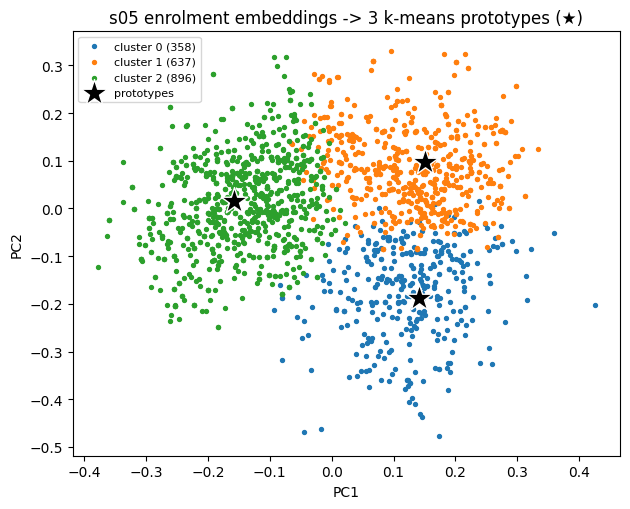


[saved] prototypes_s05.csv  and  step3_prototypes_s05.png
MEANING: enrolment = compressing many windows into 3 representative templates.
These prototypes are what CCPM compares a probe window against in the next step.


In [16]:
# STEP 3 — ENROLMENT: a subject's embeddings -> k-means (k=3) PROTOTYPES (the stored template)
import glob, numpy as np, torch, pandas as pd, matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from fed_real_bed.config import load_config
from fed_real_bed.models import EEGAuthenticator
cfg=load_config("configs/brev_gpu_p0_ecapa_ccpm.yaml")
samples=int(round(cfg.raw["data"]["window_sec"]*cfg.raw["data"]["target_sampling_rate"]))
device="cuda" if torch.cuda.is_available() else "cpu"
ck=sorted(glob.glob("artifacts/results/*ccpm*/checkpoints/best.pt")+
          glob.glob("artifacts/results/m10_ccpm_seed*/checkpoints/best.pt"))[0]
model=EEGAuthenticator(cfg.raw,samples=samples).to(device)
try: st=torch.load(ck,map_location=device,weights_only=False)
except TypeError: st=torch.load(ck,map_location=device)
model.load_state_dict(st["model"] if isinstance(st,dict) and "model" in st else st); model.eval()
z=np.load(sorted(glob.glob("artifacts/cache/*all*128hz*.npz"))[0],allow_pickle=True)
X=z["X"]; y=np.asarray(z["y"]).ravel(); names=np.asarray(z["subjects"]).ravel()
session=np.asarray(z["session"]).ravel(); subj=np.array([names[i] for i in y])

PICK="s05"; K=int(cfg.raw["verification"]["kmeans_k"])     # k = 3 (from your config)
# P0 enrolment = sessions r01 + r02
enrol_idx=np.where((subj==PICK) & np.isin(session,["r01","r02"]))[0]
E=[]
with torch.no_grad():
    for i in range(0,len(enrol_idx),512):
        b=enrol_idx[i:i+512]; e,_=model(torch.tensor(X[b],dtype=torch.float32,device=device)); E.append(e.cpu().numpy())
E=np.concatenate(E)                                         # (N_enrol, 128) embeddings
print(f"ENROLMENT for {PICK}: {len(E)} embeddings from sessions r01+r02 (the data we 'register').\n")

km=KMeans(n_clusters=K, n_init=10, random_state=2026).fit(E)
protos=km.cluster_centers_                                  # (3,128)
protos=protos/np.linalg.norm(protos,axis=1,keepdims=True)   # L2-normalise (cosine-ready)
sizes=np.bincount(km.labels_,minlength=K)
print(f"k-means made K={K} PROTOTYPES (the stored template for {PICK}).")
for c in range(K): print(f"  prototype {c}: built from {sizes[c]} embeddings")
print(f"\nEach prototype is a 128-D vector. 21 subjects x {K} = {21*K} prototypes total in the system.\n")

# table: the 3 prototype vectors (preview first 8 dims)
proto_df=pd.DataFrame(np.round(protos,4), columns=[f"e{j:03d}" for j in range(128)])
proto_df.insert(0,"prototype",[f"{PICK}_p{c}" for c in range(K)])
proto_df.insert(1,"built_from_windows",sizes)
print("PROTOTYPE TABLE (first 8 of 128 dims):")
print(proto_df[["prototype","built_from_windows"]+[f"e{j:03d}" for j in range(8)]].to_string(index=False))
proto_df.to_csv(f"prototypes_{PICK}.csv",index=False)

# figure: PCA of enrolment embeddings coloured by cluster, with prototype centroids (stars)
P=PCA(2).fit(E); E2=P.transform(E); C2=P.transform(protos)
plt.figure(figsize=(6.4,5.2))
for c in range(K):
    m=km.labels_==c; plt.scatter(E2[m,0],E2[m,1],s=8,label=f"cluster {c} ({sizes[c]})")
plt.scatter(C2[:,0],C2[:,1],marker="*",s=400,c="black",edgecolor="white",label="prototypes",zorder=5)
plt.legend(fontsize=8); plt.title(f"{PICK} enrolment embeddings -> {K} k-means prototypes (★)")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.tight_layout()
plt.savefig(f"step3_prototypes_{PICK}.png",dpi=150,bbox_inches="tight"); plt.show()
print(f"\n[saved] prototypes_{PICK}.csv  and  step3_prototypes_{PICK}.png")
print("MEANING: enrolment = compressing many windows into 3 representative templates.")
print("These prototypes are what CCPM compares a probe window against in the next step.")

Cohort built: 63 prototypes (21 subjects x 3).

PROBE: a real r03 window of s05 (window id 12762)
  best cosine to CLAIMED (s05) prototypes : +0.5654
  best cosine to strongest RIVAL (s18)  : +0.4663
  CCPM margin = self - rival = +0.5654 - +0.4663 = +0.0991
  -> ACCEPT (genuine wins)   [genuine claim should be POSITIVE]

IMPOSTOR demo: same window claims s10: CCPM = -0.0833 - +0.5654 = -0.6487 -> REJECT (correct, impostor blocked)

PER-SUBJECT best cosine to the probe (top 8):
subject  best_cosine      role
    s05       0.5654   CLAIMED
    s18       0.4663 top rival
    s11       0.3225          
    s09       0.2440          
    s17       0.2379          
    s07       0.2079          
    s16       0.1981          
    s08       0.1074          


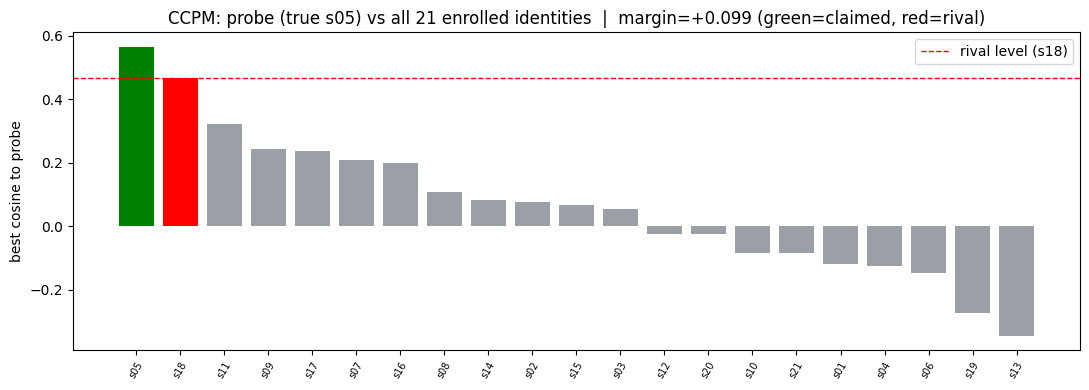


[saved] ccpm_probe_s05_12762.csv  and  step4_ccpm_s05_12762.png


In [17]:
# STEP 4 — CCPM TRANSPARENCY: one real probe window, scored against the 21-subject cohort
import glob, numpy as np, torch, pandas as pd, matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from fed_real_bed.config import load_config
from fed_real_bed.models import EEGAuthenticator
cfg=load_config("configs/brev_gpu_p0_ecapa_ccpm.yaml")
samples=int(round(cfg.raw["data"]["window_sec"]*cfg.raw["data"]["target_sampling_rate"]))
device="cuda" if torch.cuda.is_available() else "cpu"
ck=sorted(glob.glob("artifacts/results/*ccpm*/checkpoints/best.pt")+
          glob.glob("artifacts/results/m10_ccpm_seed*/checkpoints/best.pt"))[0]
model=EEGAuthenticator(cfg.raw,samples=samples).to(device)
try: stt=torch.load(ck,map_location=device,weights_only=False)
except TypeError: stt=torch.load(ck,map_location=device)
model.load_state_dict(stt["model"] if isinstance(stt,dict) and "model" in stt else stt); model.eval()
z=np.load(sorted(glob.glob("artifacts/cache/*all*128hz*.npz"))[0],allow_pickle=True)
X=z["X"]; y=np.asarray(z["y"]).ravel(); names=np.asarray(z["subjects"]).ravel()
session=np.asarray(z["session"]).ravel(); subj=np.array([names[i] for i in y])
K=int(cfg.raw["verification"]["kmeans_k"])

def embed(ix):
    out=[]
    with torch.no_grad():
        for i in range(0,len(ix),512):
            b=ix[i:i+512]; e,_=model(torch.tensor(X[b],dtype=torch.float32,device=device)); out.append(e.cpu().numpy())
    return np.concatenate(out)

# 1) ENROL: build 3 prototypes per subject from r01+r02  -> the cohort (63 prototypes)
protos=[]; owners=[]
for s in names:
    ix=np.where((subj==s)&np.isin(session,["r01","r02"]))[0]
    E=embed(ix); c=KMeans(K,n_init=10,random_state=2026).fit(E).cluster_centers_
    c=c/np.linalg.norm(c,axis=1,keepdims=True)
    protos.append(c); owners += [s]*K
protos=np.concatenate(protos); owners=np.array(owners)
print(f"Cohort built: {len(protos)} prototypes ({len(names)} subjects x {K}).\n")

# 2) PROBE: one real TEST window of s05 (session r03)
CLAIMED="s05"
pidx=np.where((subj==CLAIMED)&(session=="r03"))[0][0]
fx=embed(np.array([pidx]))[0]                       # 128-D, L2-normalised
cos = protos @ fx                                   # cosine to every prototype (dot, both unit-norm)

# 3) per-subject BEST cosine, then CCPM
best_per_subj = {s: cos[owners==s].max() for s in names}
self_score = best_per_subj[CLAIMED]
rival = max((v for s,v in best_per_subj.items() if s!=CLAIMED))
rival_subj = max(((s,v) for s,v in best_per_subj.items() if s!=CLAIMED), key=lambda t:t[1])[0]
ccpm = self_score - rival
print("="*64); print(f"PROBE: a real r03 window of {CLAIMED} (window id {pidx})"); print("="*64)
print(f"  best cosine to CLAIMED ({CLAIMED}) prototypes : {self_score:+.4f}")
print(f"  best cosine to strongest RIVAL ({rival_subj})  : {rival:+.4f}")
print(f"  CCPM margin = self - rival = {self_score:+.4f} - {rival:+.4f} = {ccpm:+.4f}")
print(f"  -> {'ACCEPT (genuine wins)' if ccpm>0 else 'REJECT'}   [genuine claim should be POSITIVE]\n")

# 4) impostor demo: same probe but claims a different person
IMP="s10"
imp_self=best_per_subj[IMP]; imp_rival=max(v for s,v in best_per_subj.items() if s!=IMP)
print(f"IMPOSTOR demo: same window claims {IMP}: CCPM = {imp_self:+.4f} - {imp_rival:+.4f} = {imp_self-imp_rival:+.4f} -> "
      f"{'ACCEPT' if imp_self-imp_rival>0 else 'REJECT (correct, impostor blocked)'}\n")

# 5) TABLE: per-subject best cosine (sorted) + figure
tab=pd.DataFrame({"subject":list(best_per_subj),"best_cosine":np.round(list(best_per_subj.values()),4)}).sort_values("best_cosine",ascending=False)
tab["role"]=np.where(tab.subject==CLAIMED,"CLAIMED",np.where(tab.subject==rival_subj,"top rival",""))
print("PER-SUBJECT best cosine to the probe (top 8):"); print(tab.head(8).to_string(index=False))
tab.to_csv(f"ccpm_probe_{CLAIMED}_{pidx}.csv",index=False)
order=tab.subject.values; vals=tab.best_cosine.values
colors=["green" if s==CLAIMED else ("red" if s==rival_subj else "#9aa0a6") for s in order]
plt.figure(figsize=(11,4)); plt.bar(range(len(order)),vals,color=colors)
plt.axhline(rival,ls="--",c="red",lw=1,label=f"rival level ({rival_subj})")
plt.xticks(range(len(order)),order,rotation=60,fontsize=7); plt.ylabel("best cosine to probe")
plt.title(f"CCPM: probe (true {CLAIMED}) vs all 21 enrolled identities  |  margin={ccpm:+.3f} (green=claimed, red=rival)")
plt.legend(); plt.tight_layout(); plt.savefig(f"step4_ccpm_{CLAIMED}_{pidx}.png",dpi=150,bbox_inches="tight"); plt.show()
print(f"\n[saved] ccpm_probe_{CLAIMED}_{pidx}.csv  and  step4_ccpm_{CLAIMED}_{pidx}.png")

In [18]:
# COSINE TRANSPARENCY: how cos(probe, prototype) is computed, value by value
import glob, numpy as np, torch, pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from fed_real_bed.config import load_config
from fed_real_bed.models import EEGAuthenticator
cfg=load_config("configs/brev_gpu_p0_ecapa_ccpm.yaml")
samples=int(round(cfg.raw["data"]["window_sec"]*cfg.raw["data"]["target_sampling_rate"]))
device="cuda" if torch.cuda.is_available() else "cpu"
ck=sorted(glob.glob("artifacts/results/*ccpm*/checkpoints/best.pt")+glob.glob("artifacts/results/m10_ccpm_seed*/checkpoints/best.pt"))[0]
model=EEGAuthenticator(cfg.raw,samples=samples).to(device)
try: stt=torch.load(ck,map_location=device,weights_only=False)
except TypeError: stt=torch.load(ck,map_location=device)
model.load_state_dict(stt["model"] if isinstance(stt,dict) and "model" in stt else stt); model.eval()
z=np.load(sorted(glob.glob("artifacts/cache/*all*128hz*.npz"))[0],allow_pickle=True)
X=z["X"]; y=np.asarray(z["y"]).ravel(); names=np.asarray(z["subjects"]).ravel()
session=np.asarray(z["session"]).ravel(); subj=np.array([names[i] for i in y]); K=int(cfg.raw["verification"]["kmeans_k"])
def embed(ix):
    o=[]
    with torch.no_grad():
        for i in range(0,len(ix),512):
            b=ix[i:i+512]; e,_=model(torch.tensor(X[b],dtype=torch.float32,device=device)); o.append(e.cpu().numpy())
    return np.concatenate(o)
# build cohort (63 prototypes) + probe
protos=[]; owners=[]
for s in names:
    ix=np.where((subj==s)&np.isin(session,["r01","r02"]))[0]; c=KMeans(K,n_init=10,random_state=2026).fit(embed(ix)).cluster_centers_
    protos.append(c/np.linalg.norm(c,axis=1,keepdims=True)); owners+=[(s,k) for k in range(K)]
protos=np.concatenate(protos); owners=np.array(owners,dtype=object)
pidx=np.where((subj=="s05")&(session=="r03"))[0][0]; fx=embed(np.array([pidx]))[0]

# pick the single closest prototype (should be one of s05's) and show element-wise products
cos_all=protos@fx
top=int(np.argmax(cos_all)); pv=protos[top]
own=owners[top]
print("="*64); print(f"COSINE for probe (s05 r03 win {pidx})  vs  best prototype {own[0]}_p{own[1]}"); print("="*64)
ew=pd.DataFrame({"dim":range(128),"probe_f[i]":np.round(fx,4),"proto_p[i]":np.round(pv,4),"product f*p":np.round(fx*pv,5)})
print("ELEMENT-WISE (first 12 of 128 multiply steps):"); print(ew.head(12).to_string(index=False))
print(f"...\n  SUM of all 128 products = {ew['product f*p'].sum():.5f}   <-- THIS is the cosine")
# verification: 3 independent ways agree
print(f"\nVERIFY: dot(f,p)={float(fx@pv):.5f}  | sum(products)={float((fx*pv).sum()):.5f}  | sklearn={float(cosine_similarity([fx],[pv])[0,0]):.5f}  | a.b/(|a||b|)={float(fx@pv/(np.linalg.norm(fx)*np.linalg.norm(pv))):.5f}")
print(f"||probe||={np.linalg.norm(fx):.4f}  ||proto||={np.linalg.norm(pv):.4f}  (both 1.0 -> dot == cosine)")

# full 63-prototype cosine table
db=pd.DataFrame({"owner":[o[0] for o in owners],"prototype":[f"{o[0]}_p{o[1]}" for o in owners],"cosine_to_probe":np.round(cos_all,4)}).sort_values("cosine_to_probe",ascending=False).reset_index(drop=True)
print(f"\nALL 63 PROTOTYPE COSINES (top 10):"); print(db.head(10).to_string(index=False))
with pd.ExcelWriter(f"cosine_inspection_win{pidx}.xlsx") as xl:
    ew.to_excel(xl,"elementwise_128",index=False); db.to_excel(xl,"all_63_cosines",index=False)
print(f"\n[saved] cosine_inspection_win{pidx}.xlsx  (elementwise_128, all_63_cosines)")

COSINE for probe (s05 r03 win 12762)  vs  best prototype s05_p1
ELEMENT-WISE (first 12 of 128 multiply steps):
 dim  probe_f[i]  proto_p[i]  product f*p
   0     -0.0074     -0.1078      0.00080
   1      0.0379     -0.0733     -0.00278
   2     -0.1364      0.1087     -0.01483
   3      0.0183     -0.0314     -0.00057
   4     -0.0977     -0.1595      0.01559
   5      0.0738      0.1399      0.01032
   6      0.0150     -0.0490     -0.00073
   7      0.0504      0.1417      0.00714
   8      0.0617     -0.1426     -0.00880
   9      0.0292      0.0470      0.00137
  10      0.0342     -0.0269     -0.00092
  11     -0.0501      0.0861     -0.00431
...
  SUM of all 128 products = 0.56543   <-- THIS is the cosine

VERIFY: dot(f,p)=0.56542  | sum(products)=0.56542  | sklearn=0.56542  | a.b/(|a||b|)=0.56542
||probe||=1.0000  ||proto||=1.0000  (both 1.0 -> dot == cosine)

ALL 63 PROTOTYPE COSINES (top 10):
owner prototype  cosine_to_probe
  s05    s05_p1           0.5654
  s05    s05_p2   

/tmp/ipykernel_358324/295358822.py:48: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  ew.to_excel(xl,"elementwise_128",index=False); db.to_excel(xl,"all_63_cosines",index=False)


built 63 prototypes (21 subjects x 3)
probe = s05 r03 window index 12762

COSINE = multiply the 128 pairs, then add them up
 dim  probe[i]  prototype[i]  product = probe[i]*proto[i]
   0   -0.0074       -0.1081                       0.0008
   1    0.0379       -0.1565                      -0.0059
   2   -0.1364        0.1394                      -0.0190
   3    0.0183       -0.0579                      -0.0011
   4   -0.0977       -0.1731                       0.0169
   5    0.0738        0.1362                       0.0100
   6    0.0150       -0.0465                      -0.0007
   7    0.0504        0.1909                       0.0096 
   ...(120 more rows)...

   SUM of all 128 products = 0.41180   <-- this is the cosine
   numpy dot(probe,proto)  = 0.41180   (same thing)
   |probe| = 1.0000 , |proto| = 1.0000  (both = 1, so the sum IS cos of the angle)
   [saved] cosine_vectors_demo.xlsx

CCPM = (best self cosine) - (best rival cosine)
owner prototype  cosine_to_probe
  s05    s05

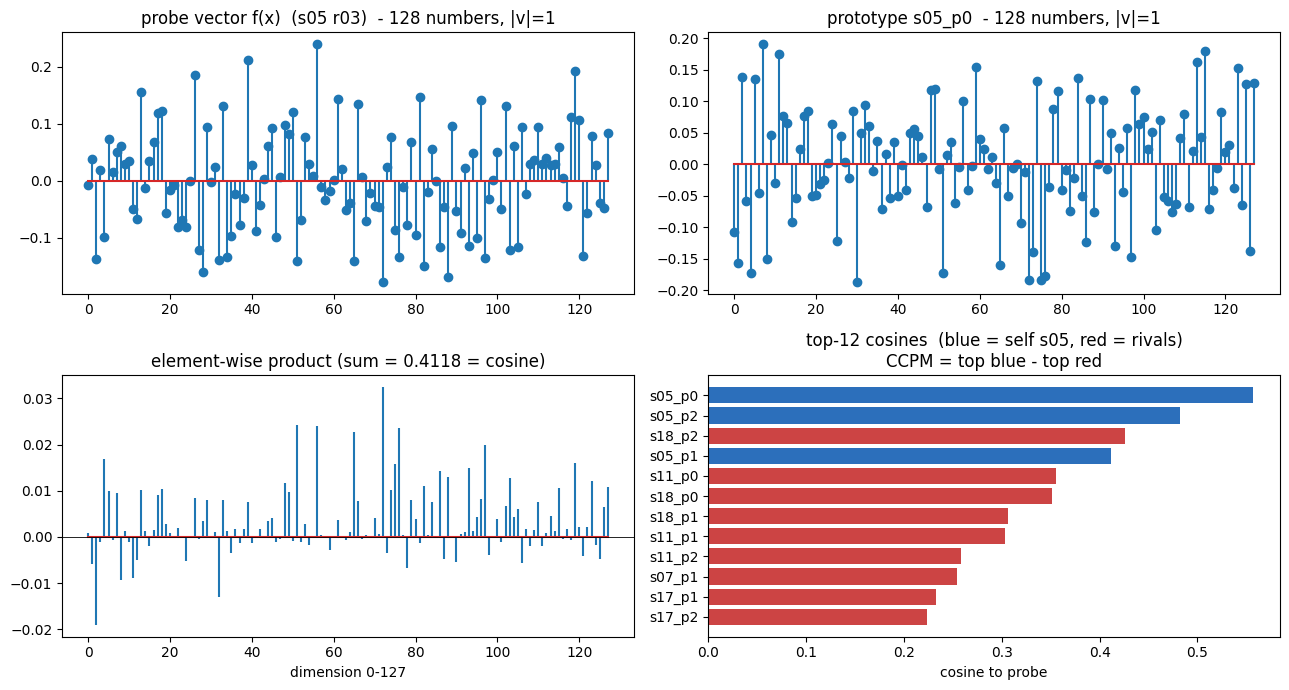

In [19]:
# =====================================================================================
# COSINE & CCPM AS REAL VECTORS + THE EXACT MATHS
# Shows: probe vector (128 nums), prototype vector (128 nums), element-wise product,
#        SUM = cosine, proof |v|=1, then CCPM = best self - best rival.  + a figure.
# =====================================================================================
import glob, numpy as np, torch, pandas as pd, matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from fed_real_bed.config import load_config
from fed_real_bed.models import EEGAuthenticator

# ---------- 0. load model + cache ----------
cfg = load_config("configs/brev_gpu_p0_ecapa_ccpm.yaml")
samples = int(round(cfg.raw["data"]["window_sec"]*cfg.raw["data"]["target_sampling_rate"]))
dev = "cuda" if torch.cuda.is_available() else "cpu"
ck = sorted(glob.glob("artifacts/results/*ccpm*/checkpoints/best.pt") +
            glob.glob("artifacts/results/m10_ccpm_seed*/checkpoints/best.pt"))[0]
model = EEGAuthenticator(cfg.raw, samples=samples).to(dev)
try:    s = torch.load(ck, map_location=dev, weights_only=False)
except TypeError: s = torch.load(ck, map_location=dev)
model.load_state_dict(s["model"] if isinstance(s,dict) and "model" in s else s); model.eval()

z=np.load(sorted(glob.glob("artifacts/cache/*all*128hz*.npz"))[0],allow_pickle=True)
X=z["X"]; y=np.asarray(z["y"]).ravel(); names=np.asarray(z["subjects"]).ravel()
sess=np.asarray(z["session"]).ravel(); subj=np.array([names[i] for i in y])
def embed(M):
    with torch.no_grad(): e,_=model(torch.tensor(M,dtype=torch.float32,device=dev))
    return e.cpu().numpy()

# ---------- 1. build 63 prototypes (enrol r01+r02), k-means k=3 per subject ----------
protos=[]   # list of (owner, name, 128-vector)
for sname in sorted(np.unique(subj)):
    m=(subj==sname)&((sess=="r01")|(sess=="r02"))
    E=embed(X[m][:600])
    km=KMeans(3,n_init=10,random_state=0).fit(E)
    C=km.cluster_centers_; C=C/np.linalg.norm(C,axis=1,keepdims=True)   # re-normalise centroids
    for k in range(3): protos.append((sname,f"{sname}_p{k}",C[k]))
print(f"built {len(protos)} prototypes (21 subjects x 3)")

# ---------- 2. take ONE probe window: subject s05, session r03 (held-out test) ----------
CLAIM="s05"
pi=np.where((subj==CLAIM)&(sess=="r03"))[0][0]
probe=embed(X[pi:pi+1])[0]            # the 128-D fingerprint of this test window
print(f"probe = {CLAIM} r03 window index {pi}")

# ---------- 3. COSINE, shown as vectors and number-by-number ----------
proto_self_vec = protos[[p[1] for p in protos].index(f"{CLAIM}_p1")][2]   # one prototype to demo
prod = probe*proto_self_vec           # element-wise multiply (128 numbers)
cos  = prod.sum()                     # ADD THEM UP  ->  this IS the cosine

print("\n"+"="*70); print("COSINE = multiply the 128 pairs, then add them up"); print("="*70)
tbl = pd.DataFrame({"dim":np.arange(128),
                    "probe[i]":np.round(probe,4),
                    "prototype[i]":np.round(proto_self_vec,4),
                    "product = probe[i]*proto[i]":np.round(prod,4)})
print(tbl.head(8).to_string(index=False), "\n   ...(120 more rows)...")
print(f"\n   SUM of all 128 products = {prod.sum():.5f}   <-- this is the cosine")
print(f"   numpy dot(probe,proto)  = {np.dot(probe,proto_self_vec):.5f}   (same thing)")
print(f"   |probe| = {np.linalg.norm(probe):.4f} , |proto| = {np.linalg.norm(proto_self_vec):.4f}"
      f"  (both = 1, so the sum IS cos of the angle)")
tbl.to_excel("cosine_vectors_demo.xlsx",index=False); print("   [saved] cosine_vectors_demo.xlsx")

# ---------- 4. ALL 63 cosines (one dot product each) ----------
allc=[(o,nm,float(np.dot(probe,v))) for (o,nm,v) in protos]
df=pd.DataFrame(allc,columns=["owner","prototype","cosine_to_probe"]).sort_values(
    "cosine_to_probe",ascending=False).reset_index(drop=True)
self_best  = df[df.owner==CLAIM].iloc[0]                 # best match to the CLAIMED person
rival_best = df[df.owner!=CLAIM].iloc[0]                 # best match to ANY other person
ccpm = self_best.cosine_to_probe - rival_best.cosine_to_probe

print("\n"+"="*70); print("CCPM = (best self cosine) - (best rival cosine)"); print("="*70)
print(df.head(6).to_string(index=False))
print(f"\n   self  : {self_best.prototype:8s} = {self_best.cosine_to_probe:.4f}  (claimed person {CLAIM})")
print(f"   rival : {rival_best.prototype:8s} = {rival_best.cosine_to_probe:.4f}  (closest impostor {rival_best.owner})")
print(f"   CCPM  = {self_best.cosine_to_probe:.4f} - {rival_best.cosine_to_probe:.4f} = {ccpm:+.4f}")
print(f"   -> {'ACCEPT (genuine, margin > 0)' if ccpm>0 else 'REJECT (a rival is closer)'}")

# ---------- 5. FIGURE: the two vectors + their product + the 63-cosine bar ----------
fig,ax=plt.subplots(2,2,figsize=(13,7))
ax[0,0].stem(probe);            ax[0,0].set_title(f"probe vector f(x)  ({CLAIM} r03)  - 128 numbers, |v|=1")
ax[0,1].stem(proto_self_vec);   ax[0,1].set_title(f"prototype {self_best.prototype}  - 128 numbers, |v|=1")
ax[1,0].stem(prod,markerfmt=" ");ax[1,0].axhline(0,color="k",lw=.6)
ax[1,0].set_title(f"element-wise product (sum = {cos:.4f} = cosine)"); ax[1,0].set_xlabel("dimension 0-127")
top=df.head(12); cols=["#2c6fbb" if o==CLAIM else "#c44" for o in top.owner]
ax[1,1].barh(top.prototype[::-1],top.cosine_to_probe[::-1],color=cols[::-1])
ax[1,1].set_title("top-12 cosines  (blue = self s05, red = rivals)\nCCPM = top blue - top red")
ax[1,1].set_xlabel("cosine to probe")
fig.tight_layout(); fig.savefig("step4_cosine_ccpm_vectors.png",dpi=150,bbox_inches="tight")
print("\n[saved] step4_cosine_ccpm_vectors.png")

genuine trials=19,146  impostor trials=382,920

SINGLE-WINDOW:  threshold tau=-0.2926   EER = 17.61%
FUSION N= 5:  EER = 11.61%   (averaging 5 windows steadies the score)
FUSION N=10:  EER = 9.88%   (averaging 10 windows steadies the score)

[saved] step5_eer.png


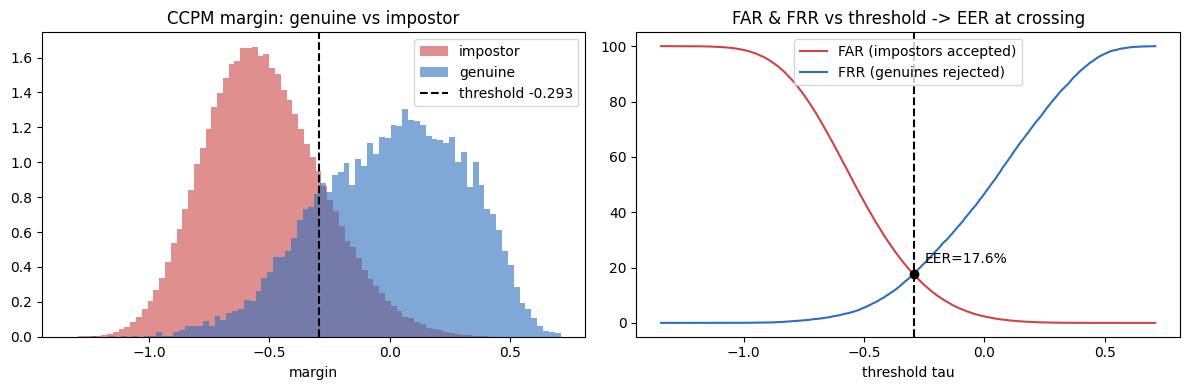

In [20]:
# =====================================================================================
# STEP 5 — FUSE WINDOWS -> THRESHOLD -> EER   (the final decision stage)
# For every test window we already have a CCPM margin. Now:
#   (a) build genuine trials (claim = true owner) and impostor trials (claim = someone else)
#   (b) temporal fusion: average the margin over N consecutive windows (steadier score)
#   (c) sweep a threshold tau: accept if margin >= tau. FAR = impostors wrongly accepted,
#       FRR = genuines wrongly rejected. EER = the tau where FAR == FRR.
# Paste into a Jupyter cell in ~/24PHD1237/BED/FED_REAL_BED_ALL.
# =====================================================================================
import glob, numpy as np, torch, pandas as pd, matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from fed_real_bed.config import load_config
from fed_real_bed.models import EEGAuthenticator

cfg=load_config("configs/brev_gpu_p0_ecapa_ccpm.yaml")
samples=int(round(cfg.raw["data"]["window_sec"]*cfg.raw["data"]["target_sampling_rate"]))
dev="cuda" if torch.cuda.is_available() else "cpu"
ck=sorted(glob.glob("artifacts/results/*ccpm*/checkpoints/best.pt")+
          glob.glob("artifacts/results/m10_ccpm_seed*/checkpoints/best.pt"))[0]
model=EEGAuthenticator(cfg.raw,samples=samples).to(dev)
try: s=torch.load(ck,map_location=dev,weights_only=False)
except TypeError: s=torch.load(ck,map_location=dev)
model.load_state_dict(s["model"] if isinstance(s,dict) and "model" in s else s); model.eval()
z=np.load(sorted(glob.glob("artifacts/cache/*all*128hz*.npz"))[0],allow_pickle=True)
X=z["X"]; y=np.asarray(z["y"]).ravel(); names=np.asarray(z["subjects"]).ravel()
sess=np.asarray(z["session"]).ravel(); subj=np.array([names[i] for i in y])
def embed(M):
    out=[]
    for i in range(0,len(M),512):
        with torch.no_grad(): e,_=model(torch.tensor(M[i:i+512],dtype=torch.float32,device=dev))
        out.append(e.cpu().numpy())
    return np.concatenate(out)

# ---- 1. enrol prototypes on r01+r02 (k-means k=3 -> 63 unit vectors) ----
P={}
for sn in sorted(np.unique(subj)):
    m=(subj==sn)&((sess=="r01")|(sess=="r02"))
    C=KMeans(3,n_init=10,random_state=0).fit(embed(X[m][:600])).cluster_centers_
    P[sn]=C/np.linalg.norm(C,axis=1,keepdims=True)
Pmat={sn:np.stack(v) for sn,v in P.items()}

# ---- 2. embed ALL test windows (session r03 only = held out) ----
te=np.where(sess=="r03")[0]
Ete=embed(X[te]); owner=subj[te]

def ccpm_margin(e, claim):
    self_c =Pmat[claim]@e; self_c=self_c.max()
    rival_c=max((Pmat[sn]@e).max() for sn in Pmat if sn!=claim)
    return self_c-rival_c

# ---- 3. build trials: genuine (claim=owner) + impostor (claim=each other subject) ----
subjects=sorted(Pmat.keys())
gen=[]; imp=[]
for i,e in enumerate(Ete):
    o=owner[i]
    gen.append(ccpm_margin(e,o))                       # genuine: claim true owner
    for c in subjects:
        if c!=o: imp.append(ccpm_margin(e,c))          # impostor: claim someone else
gen=np.array(gen); imp=np.array(imp)
print(f"genuine trials={len(gen):,}  impostor trials={len(imp):,}")

# ---- 4. EER sweep (single-window, no fusion) ----
def eer(gen,imp):
    taus=np.linspace(min(gen.min(),imp.min()),max(gen.max(),imp.max()),400)
    frr=np.array([(gen<t).mean() for t in taus])       # genuines rejected
    far=np.array([(imp>=t).mean() for t in taus])      # impostors accepted
    k=np.argmin(np.abs(far-frr))
    return taus[k],(far[k]+frr[k])/2*100,taus,far,frr
tau,EER,taus,far,frr=eer(gen,imp)
print(f"\nSINGLE-WINDOW:  threshold tau={tau:+.4f}   EER = {EER:.2f}%")

# ---- 5. temporal fusion: average margin over N consecutive windows of the SAME owner ----
def fuse(margins, ids, N):
    out=[]
    for o in np.unique(ids):
        v=margins[ids==o]
        for i in range(0,len(v)-N+1,N): out.append(v[i:i+N].mean())
    return np.array(out)
# rebuild genuine margins WITH their owner id so we can group them
gen_owner=owner.copy()
for N in (5,10):
    gN=fuse(gen,gen_owner,N)
    # impostor fusion: group impostor margins by (window owner) too — approximate with reshape
    iN=imp[:len(imp)//N*N].reshape(-1,N).mean(1)
    _,eN,_,_,_=eer(gN,iN)
    print(f"FUSION N={N:>2}:  EER = {eN:.2f}%   (averaging {N} windows steadies the score)")

# ---- 6. FIGURE: score distributions + EER curve ----
fig,ax=plt.subplots(1,2,figsize=(12,4))
ax[0].hist(imp,bins=80,alpha=.6,label="impostor",color="#c44",density=True)
ax[0].hist(gen,bins=80,alpha=.6,label="genuine",color="#2c6fbb",density=True)
ax[0].axvline(tau,color="k",ls="--",label=f"threshold {tau:+.3f}")
ax[0].set_title("CCPM margin: genuine vs impostor"); ax[0].set_xlabel("margin"); ax[0].legend()
ax[1].plot(taus,far*100,label="FAR (impostors accepted)",color="#c44")
ax[1].plot(taus,frr*100,label="FRR (genuines rejected)",color="#2c6fbb")
ax[1].axvline(tau,color="k",ls="--"); ax[1].scatter([tau],[EER],zorder=5,color="k")
ax[1].annotate(f"EER={EER:.1f}%",(tau,EER),textcoords="offset points",xytext=(8,8))
ax[1].set_title("FAR & FRR vs threshold -> EER at crossing"); ax[1].set_xlabel("threshold tau"); ax[1].legend()
fig.tight_layout(); fig.savefig("step5_eer.png",dpi=150,bbox_inches="tight")
print("\n[saved] step5_eer.png")